In this report, we will perform a three stage analysis to demonstrate the reason, performance, and evluation matrix behind our model


1. Data Analysis

In [2]:
import warnings
warnings.filterwarnings('ignore')
# matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
#using StratifiedKFold for cross validations. (n_splits= 5)

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    # roc_curve, precision_recall_curve, average_precision_score,
    f1_score, ConfusionMatrixDisplay
)
import lightgbm as lgb

In [3]:
BASE = Path("Documents/_MyDrive/Interviews/Nasdaq")
TRAIN_PATH = BASE / "train_fraud.parquet"
TEST_PATH  = BASE / "test_fraud_external.parquet"
OUT_PATH   = BASE / "test_fraud_external_predicted.parquet"

In [5]:

PLOT_DIR   = BASE / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
PALETTE = {'fraud': '#e74c3c', 'legit': '#2980b9'}

First we will load the data:


In [6]:
#1.Load Data

print("\n" + "="*60)
print("1. LOADING DATA")
print("="*60)

train = pd.read_parquet(TRAIN_PATH)
test  = pd.read_parquet(TEST_PATH)

print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}")
print(f"Train columns: {train.columns.tolist()}")
print(f"\nTrain dtypes:\n{train.dtypes}")
print(f"\nMissing values (train):\n{train.isnull().sum()}")
print(f"\nFraud rate : {train['is_fraud'].mean()*100:.4f}%")
print(f"Fraud count: {train['is_fraud'].sum():,} / {len(train):,}")
print(f"\nTransaction types:\n{train['transaction_type'].value_counts()}")
print(f"\nBasic stats:\n{train[['transaction_amount','initiater_balance_before','recipient_balance_before']].describe()}")



1. LOADING DATA


ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.

In [ ]:
# ── Plot 1: Target distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = train['is_fraud'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], counts.values,
            color=[PALETTE['legit'], PALETTE['fraud']], edgecolor='black', linewidth=0.5)
axes[0].set_title('Transaction Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(train)*100:.4f}%)', ha='center', fontsize=9)

axes[1].pie(counts.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.4f%%', colors=[PALETTE['legit'], PALETTE['fraud']],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Balance (extremely imbalanced)', fontweight='bold')

plt.tight_layout()
#in dyou would  oe ypse
# plt.savefig(PLOT_DIR / "01_class_distribution.png", bbox_inches='tight')
# plt.close()
# print("  Saved: 01_class_distribution.png")
plt.show()

With all the data we have, we would like to understand the class balance first, otherwise we might train a model that just predicts "legitimate" for everything and still gets 99.99% accuracy, which is completely useless.

Based on the training data that was provided, the possibility of having a fraud is extremely rare. 357 fraud vs 3,143,740 legitimate, a 1-in-8,806 imbalance. This immediately tells us the model needs special handling (like is_unbalance=True) and that accuracy is a misleading metric.

Therefore, we considered different models to try out to see if we can get a higher recall rate

**2)Transcation Type vs Fraud**

We want to know if fraud concentrates in certain transaction types. The two charts answer slightly different questions: Left shows raw fraud/legit counts per transaction type, right shows fraud rate (%) per type

In [ ]:
# ── Plot 2: Transaction type vs fraud ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_counts = train.groupby(['transaction_type', 'is_fraud']).size().unstack(fill_value=0)
type_counts.columns = ['Legitimate', 'Fraud']
type_counts.plot(kind='bar', ax=axes[0],
                 color=[PALETTE['legit'], PALETTE['fraud']],
                 edgecolor='black', linewidth=0.5)
axes[0].set_title('Transaction Type: Legit vs Fraud (Count)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

fraud_rate_by_type = train.groupby('transaction_type')['is_fraud'].mean() * 100
fraud_rate_by_type.sort_values(ascending=False).plot(kind='bar', ax=axes[1],
    color=PALETTE['fraud'], edgecolor='black', linewidth=0.5)
axes[1].set_title('Fraud Rate (%) by Transaction Type', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(fraud_rate_by_type.sort_values(ascending=False)):
    axes[1].text(i, v + 0.001, f'{v:.4f}%', ha='center', fontsize=8)

plt.tight_layout()
# plt.savefig(PLOT_DIR / "02_transaction_type.png", bbox_inches='tight')
# plt.close()
plt.show()
# print("  Saved: 02_transaction_type.png")
print(f"  Fraud by type:\n{train.groupby('transaction_type')['is_fraud'].agg(['sum','mean']).round(4)}")




From current chart we can see that fraud only exists in CASH_OUT and TRANSFER. The rate chart reveals TRANSFER is actually more risky per transaction (0.032%) than CASH_OUT (0.019%), even though CASH_OUT has more total frauds. This is a key feature for the model


**3) Amount distribution**

*  Left is an overlapping histogram of transaction amounts for fraud vs legit.
*  Right is a boxplot of amounts by transaction type.



Here we used $log(n+1)$ distribution.

Because we have transaction amounts range from $0 to $73M, those raw values would squash everything into one corner of the chart, make it harder to spot the difference since the scale is dominated by extreme values. However, by using Log, it compresses the scale so we can see the full shape of the distribution. Also because some transactions have amount = 0, and $log(0)$ is mathematically undefined (negative infinity). Adding 1 shifts all values up by 1 first, so zero safely maps to $log(1) = 0$.

In [ ]:


# ── Plot 3: Amount distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

legit_amounts = train[train['is_fraud']==0]['transaction_amount']
fraud_amounts = train[train['is_fraud']==1]['transaction_amount']

axes[0].hist(np.log1p(legit_amounts), bins=60, color=PALETTE['legit'], alpha=0.7,
             label='Legitimate', density=True)
axes[0].hist(np.log1p(fraud_amounts), bins=60, color=PALETTE['fraud'], alpha=0.8,
             label='Fraud', density=True)
axes[0].set_title('log(n+1) Distribution by Class', fontweight='bold')
axes[0].set_xlabel('log(n + 1)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Amount stats by class
amount_stats = train.groupby('is_fraud')['transaction_amount'].describe()
print(f"\n  Amount stats by class:\n{amount_stats}")

# Amount by type for fraud
axes[1].boxplot(
    [np.log1p(train[train['transaction_type']==t]['transaction_amount'])
     for t in sorted(train['transaction_type'].unique())],
    labels=sorted(train['transaction_type'].unique()),
    patch_artist=True,
    medianprops=dict(color='red', linewidth=2)
)
axes[1].set_title('log(n+1) by Transaction Type', fontweight='bold')
axes[1].set_ylabel('log(n + 1)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()
# plt.savefig(PLOT_DIR / "03_amount_distribution.png", bbox_inches='tight')
plt.close()

# print("  Saved: 03_amount_distribution.png")

Fraud amounts skew much higher (mean \$1.5M vs \$217K). The distributions overlap but fraud is clearly shifted right on the log scale. From further analysis, Fraud shifts right simply because fraudulent transactions involve much larger amounts, the median fraud transaction (\$350K) is nearly 3 times larger than the median legit transaction (\$121K).

This shift also showed us transaction amount is a useful but imperfect signal. It's not that all large transactions are fraud since plenty of legit transactions are also large (up to \$73M). But if we see a very large amount combined with other signals (such as, CASH_OUT type, account drain), the probability of fraud rises significantly.


**4) Time Analysis, Time series?**

In [ ]:


# ── Plot 4: Time analysis ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

fraud_by_hour = train[train['is_fraud']==1].groupby('hours_elapsed').size()
legit_by_hour = train[train['is_fraud']==0].groupby('hours_elapsed').size()

# Normalize to rate per transaction
fraud_rate_by_hour = train.groupby('hours_elapsed')['is_fraud'].mean() * 100
txn_vol_by_hour   = train.groupby('hours_elapsed').size()

ax2 = axes[0].twinx()
axes[0].fill_between(txn_vol_by_hour.index, txn_vol_by_hour.values,
                     alpha=0.3, color=PALETTE['legit'], label='Transaction volume')
ax2.plot(fraud_rate_by_hour.index, fraud_rate_by_hour.values,
         color=PALETTE['fraud'], linewidth=1, alpha=0.6, label='Fraud rate')
rolling = fraud_rate_by_hour.rolling(12, center=True).mean()
ax2.plot(rolling.index, rolling.values, color='darkred', linewidth=2.5, label='12h rolling avg')
axes[0].set_title('Transaction Volume and Fraud Rate Over 744 Hours', fontweight='bold')
axes[0].set_ylabel('Transaction Count', color=PALETTE['legit'])
ax2.set_ylabel('Fraud Rate (%)', color=PALETTE['fraud'])
axes[0].legend(loc='upper left')
ax2.legend(loc='upper right')

# Hourly pattern
hour_fraud_rate = train.copy()
hour_fraud_rate['hour_of_day'] = hour_fraud_rate['hours_elapsed'] % 24
hourly = hour_fraud_rate.groupby('hour_of_day')['is_fraud'].mean() * 100
hourly_vol = hour_fraud_rate.groupby('hour_of_day').size()
axes[1].bar(hourly.index, hourly.values, color=PALETTE['fraud'], alpha=0.8, label='Fraud rate (%)')
axes[1].set_title('Fraud Rate by Hour of Day', fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.savefig(PLOT_DIR / "04_time_analysis.png", bbox_inches='tight')
plt.show()
# plt.close()
# print("  Saved: 04_time_analysis.png")

We choose to use the 12hr rolling average to avoid noisy. With only 357 fraud cases across 744 hours, the per-hour fraud rate is extremely noisy, with most hours have 0 fraud, some spike to 20. A 12-hour rolling average smooths this out to reveal the underlying trend rather than noise.

Through those 2 charts, we found that fraud bursts rather than being steady. The hour-of-day chart shows fraud is disproportionately concentrated at night (36% of fraud at 10pm–6am vs only 6% of legit). And it all happened in the last 108 hours(in the 12 hr rolling bases)





**Is timeseries analysis possible?**

Based on this new feature finding, another suggestion here is we can use time series to predict before the fraud actually happened.

wecan use feautures as below as an indicator:

→ Burst detection: many frauds in a short window signals an attack wave

→ Velocity features: same account transacting multiple times within 1 hour

→ Hour-of-day seasonality: systematically higher fraud rate at night

→ End-of-month patterns: if this pattern holds across multiple months


However, there are also difficuties here:

→ Only 1 month of data — too short for reliable seasonal modelling

→ No repeat offenders — every fraud is a unique account, so per-account
  time series aren't possible

→ Fraud is so rare (357 cases) that a time series model has almost no
  signal to learn from

In real wolrd situation, we will have more comprehenisve data, transcational historys, and apply Timeseries analysis for fraud prediction. So we can actualy detect fraud transction based on those features and block it  before it actually happened. Rather than flag the transaction after it occured. It saves time for staff inverstigation and provieded a better customer serices experiences(safer) for the customers.

Therefore, with limited data here, rather than predicting when fraud will happen with a time series model, a better approach would be adding velocity and burst features to the existing model:

Features a time-aware model could add:

*   txns_from_same_account_last_1h'    # how many transactions from this account recently?
*   'txns_to_same_recipient_last_24h'   # is money flowing repeatedly to same destination?
*   'fraud_rate_in_last_12h_window'     # is there a fraud wave happening right now?

*  'hour_of_day_fraud_rate'            # historical fraud rate for this hour






**5) Balance Analysis**

In [ ]:
# ── Plot 5: Balance analysis ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# ── Top-left: Account Drain — dual y-axis to show both classes ────────────────

# left axis = legit counts, right axis = fraud counts.
train_copy = train.copy()
train_copy['drains_account'] = (
    (train_copy['initiater_balance_before'] > 0) &
    (np.abs(train_copy['transaction_amount'] - train_copy['initiater_balance_before']) < 1.0)
).astype(int)

drain_counts = train_copy.groupby(['drains_account', 'is_fraud']).size().unstack(fill_value=0)
drain_counts.index = ['Does NOT\ndrain', 'Drains\naccount']
drain_counts.columns = ['Legitimate', 'Fraud']

x = np.arange(len(drain_counts))
width = 0.35
ax_r = axes[0][0].twinx()   # right axis for fraud

bars_l = axes[0][0].bar(x - width/2, drain_counts['Legitimate'], width,
                         color=PALETTE['legit'], edgecolor='black', linewidth=0.5,
                         label='Legitimate (left axis)')
bars_r = ax_r.bar(x + width/2, drain_counts['Fraud'], width,
                   color=PALETTE['fraud'], edgecolor='black', linewidth=0.5,
                   label='Fraud (right axis)')

axes[0][0].set_title('Account Drain: Legit vs Fraud\n(dual axis — scales differ)', fontweight='bold')
axes[0][0].set_ylabel('Legitimate Count', color=PALETTE['legit'])
ax_r.set_ylabel('Fraud Count', color=PALETTE['fraud'])
axes[0][0].set_xticks(x)
axes[0][0].set_xticklabels(drain_counts.index)
axes[0][0].tick_params(axis='y', colors=PALETTE['legit'])
ax_r.tick_params(axis='y', colors=PALETTE['fraud'])

# Label bars with counts
for bar in bars_l:
    axes[0][0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8,
                    color=PALETTE['legit'])
for bar in bars_r:
    ax_r.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
              f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=8,
              color=PALETTE['fraud'])

lines_l, labels_l = axes[0][0].get_legend_handles_labels()
lines_r, labels_r = ax_r.get_legend_handles_labels()
axes[0][0].legend(lines_l + lines_r, labels_l + labels_r, fontsize=7, loc='upper center')

# Finding annotation
drain_fraud_pct = drain_counts.loc['Drains\naccount', 'Fraud'] / drain_counts['Fraud'].sum() * 100
drain_legit_pct = drain_counts.loc['Drains\naccount', 'Legitimate'] / drain_counts['Legitimate'].sum() * 100
axes[0][0].text(0.5, -0.18,
    f'Finding: {drain_fraud_pct:.0f}% of fraud drains the account vs only {drain_legit_pct:.1f}% of legit',
    transform=axes[0][0].transAxes, ha='center', fontsize=8,
    color='darkred', style='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffe5e5', edgecolor='#e74c3c', alpha=0.8))

# ── Top-right: Initiator Balance Before ───────────────────────────────────────
# What to look for: do fraudsters start with more or less money than legit senders?
legit_init = np.log1p(train[train['is_fraud']==0]['initiater_balance_before'].clip(lower=0))
fraud_init = np.log1p(train[train['is_fraud']==1]['initiater_balance_before'].clip(lower=0))
axes[0][1].hist(legit_init, bins=50, color=PALETTE['legit'], alpha=0.7, label='Legitimate', density=True)
axes[0][1].hist(fraud_init, bins=50, color=PALETTE['fraud'], alpha=0.8, label='Fraud', density=True)
axes[0][1].set_title('log(Initiator Balance Before + 1) by Class', fontweight='bold')
axes[0][1].set_xlabel('log(Balance + 1)')
axes[0][1].set_ylabel('Density')
axes[0][1].legend()

legit_zero_pct = (train[train['is_fraud']==0]['initiater_balance_before'] == 0).mean() * 100
fraud_zero_pct = (train[train['is_fraud']==1]['initiater_balance_before'] == 0).mean() * 100
axes[0][1].text(0.5, -0.18,
    f'Finding: {fraud_zero_pct:.0f}% of fraud starts at $0 vs {legit_zero_pct:.0f}% of legit — fraudsters have real money before striking',
    transform=axes[0][1].transAxes, ha='center', fontsize=8,
    color='darkred', style='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffe5e5', edgecolor='#e74c3c', alpha=0.8))

# ── Bottom-left: Recipient Balance Before ─────────────────────────────────────
# What to look for: are fraud recipients "mule" accounts that start empty?
legit_recip = np.log1p(train[train['is_fraud']==0]['recipient_balance_before'].clip(lower=0))
fraud_recip = np.log1p(train[train['is_fraud']==1]['recipient_balance_before'].clip(lower=0))
axes[1][0].hist(legit_recip, bins=50, color=PALETTE['legit'], alpha=0.7, label='Legitimate', density=True)
axes[1][0].hist(fraud_recip, bins=50, color=PALETTE['fraud'], alpha=0.8, label='Fraud', density=True)
axes[1][0].set_title('log(Recipient Balance Before + 1) by Class', fontweight='bold')
axes[1][0].set_xlabel('log(Balance + 1)')
axes[1][0].set_ylabel('Density')
axes[1][0].legend()

fraud_recip_zero = (train[train['is_fraud']==1]['recipient_balance_before'] == 0).mean() * 100
legit_recip_zero = (train[train['is_fraud']==0]['recipient_balance_before'] == 0).mean() * 100
axes[1][0].text(0.5, -0.18,
    f'Finding: {fraud_recip_zero:.0f}% of fraud recipients start at $0 vs {legit_recip_zero:.0f}% of legit — recipient accounts are often empty shells',
    transform=axes[1][0].transAxes, ha='center', fontsize=8,
    color='darkred', style='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffe5e5', edgecolor='#e74c3c', alpha=0.8))

# ── Bottom-right: Initiator Balance Decrease ──────────────────────────────────

train_copy['init_balance_change'] = (train_copy['initiater_balance_before']
                                     - train_copy['initiater_balance_after'])
legit_change = np.log1p(train_copy[train_copy['is_fraud']==0]['init_balance_change'].clip(lower=0))
fraud_change = np.log1p(train_copy[train_copy['is_fraud']==1]['init_balance_change'].clip(lower=0))
axes[1][1].hist(legit_change, bins=50, color=PALETTE['legit'], alpha=0.7, label='Legitimate', density=True)
axes[1][1].hist(fraud_change, bins=50, color=PALETTE['fraud'], alpha=0.8, label='Fraud', density=True)
axes[1][1].set_title('log(Initiator Balance Decrease + 1) by Class', fontweight='bold')
axes[1][1].set_xlabel('log(Balance Decrease + 1)')
axes[1][1].set_ylabel('Density')
axes[1][1].legend()

fraud_med_decrease = train_copy[train_copy['is_fraud']==1]['init_balance_change'].median()
legit_med_decrease = train_copy[train_copy['is_fraud']==0]['init_balance_change'].clip(lower=0).median()
axes[1][1].text(0.5, -0.18,
    f'Finding: median balance decrease — Fraud ${fraud_med_decrease:,.0f} vs Legit ${legit_med_decrease:,.0f} — fraud drains far more per transaction',
    transform=axes[1][1].transAxes, ha='center', fontsize=8,
    color='darkred', style='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffe5e5', edgecolor='#e74c3c', alpha=0.8))

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()
# plt.savefig(PLOT_DIR / "05_balance_analysis.png", bbox_inches='tight')
# plt.close()
print("  Saved: 05_balance_analysis.png")

**Top-left — Account Drain:**
It's a classic fraud patterns that someone steal everything at once. So we would like to know if the fraud transaction actually drains the account. And based on our result: 97.8% of fraud transactions drain the account completely (amount ≈ balance before), versus only 0.001% of legit transactions. In a way, it proved our hypotheses that fraud transactions turn to drain the account completely, it is the single most powerful signal in the entire dataset by far!

However, being reasonable caucious here. Since we only have data for one month, and ideally, we'd test on a hold-out month of data, not just cross-validation within the dame month. So this near-perfect performance is a warning sign as as a success.

In order to count on that possibility, instead of the hardf binary Drains_account, we used the continous version:
`df['amount_to_init_ratio'] = df['transaction_amount'] / (df['initiater_balance_before'] + 1)
`
So the model can catches 50%, 80%, 95% account drains, not only the 100% ones.


**Top-right — log(Initiator Balance Before+1):**

This chart shows distribution of how much money the initiator had before the transaction, by class. We used the log distribution (for the same reason as Plot 3) because of the balances is heavily skewed.
In short, I found that:

*	Both distributions have a big spike at 0  →  many accounts start empty (both fraud and legit)
*	Legit has more mass between $log 10–12$  →  most legit senders have $22K–$163K
*	Fraud has more mass between $log 12–14$  →  most fraudsters have $163K–$1.2M (higher than the legit accounts)


This tells us an important information that fraudsters tend to have larger balances before striking, which means they target accounts with money.
One notes here is: You can't just say "if balance > $X → fraud" because many legit transactions also come from large accounts, same that many fraud transactions also come from smaller accounts. This is why we use a machine learning model rather than a simple rule, so that the model combines this feature with many others (amount, transaction type, drain signal, etc.) to make a good prediction. No single feature is enough alone. which we will apply later in our ML model for detailed explanation.



**Bottom-left — log(Recipient Balance Before+1):**

Same idea but for the recipient's balance before receiving the transaction.
66% of fraud recipients start with $0, vs 50% of legit recipients. Fraud money is being sent into empty shell accounts, I suspect those accounts with no prior activity, are set up specifically to receive stolen funds.

**Bottom-right — log(Initiator Balance Decrease+1):**

“balance_before” – “balance_after” = how much money left the initiator's account.
More in detail, fraud median balance decrease is ~\$350K vs ~\$0 for legit (legit median is $0 because CASH_IN and PAYMENT types don't decrease the initiator's balance at all). Which provs that Fraud transactions drain a massive amount in a single hit.


**6) Existing fraud flag analysis**

From given file: column.txt, and the column present in both parquet files.



```
is_fraud_flagged: did the system flag the transaction as fraud
                  (1 for flagged fraud, 0 for not)
```


This single line tells us that there is a pre-existing automate system already.
Also, it tells us


1.   It produces a binary output (1 = flagged, 0 = not flagged)

2.   It runs before any manual review — hence "flagged"


And the parquet files confirm it.

Therefore, we can take a look at how current flagging system doing?


In [ ]:
# ── Plot 6: Existing fraud flag analysis ──────────────────────────────────────


import matplotlib.patches as mpatches
from sklearn.metrics import classification_report

PALETTE  = {'fraud': '#e74c3c', 'legit': '#2980b9', 'miss': '#bdc3c7', 'catch': '#e74c3c'}


# ── Core stats
actual_fraud = train['is_fraud'].sum()           # 357
flagged      = train['is_flagged_fraud'].sum()   # 2
tp = ((train['is_flagged_fraud']==1) & (train['is_fraud']==1)).sum()  # 2
fp = ((train['is_flagged_fraud']==1) & (train['is_fraud']==0)).sum()  # 0
fn = ((train['is_flagged_fraud']==0) & (train['is_fraud']==1)).sum()  # 355
precision = tp / flagged if flagged > 0 else 0   # 1.0
recall    = tp / actual_fraud                     # 0.0056
f1        = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Is the Existing Flag System Effective?',
             fontweight='bold', fontsize=14, y=1.01)

# ── Panel A: Metric bar chart
metrics     = ['Precision', 'Recall', 'F1-Score']
flag_scores = [precision, recall, f1]
perfect     = [1.0, 1.0, 1.0]
x     = np.arange(len(metrics))
width = 0.35

bars1 = axes[0].bar(x - width/2, flag_scores, width,
                    color=['#e74c3c','#e74c3c','#e74c3c'],
                    edgecolor='black', linewidth=0.5, label='Current Flag System')
bars2 = axes[0].bar(x + width/2, perfect, width,
                    color=['#2ecc71','#2ecc71','#2ecc71'],
                    alpha=0.4, edgecolor='black', linewidth=0.5,
                    linestyle='--', label='Perfect System (reference)')

for bar, val in zip(bars1, flag_scores):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{val:.3f}', ha='center', fontsize=10,
                 fontweight='bold', color='darkred')

axes[0].set_ylim(0, 1.25)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score')
axes[0].set_title('Flag System Metrics\nvs Perfect Reference', fontweight='bold')
axes[0].legend()
axes[0].axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
axes[0].text(0.98, 0.52, '0.5 baseline', transform=axes[0].transAxes,
             ha='right', fontsize=8, color='gray')
axes[0].text(0.5, -0.12,
    f'Precision=1.0 looks good but Recall={recall:.3f}\n'
    f'means it misses {fn} of {actual_fraud} actual frauds',
    transform=axes[0].transAxes, ha='center', fontsize=9,
    color='darkred', style='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffe5e5',
              edgecolor='#e74c3c', alpha=0.8))

# ── Panel B: Waffle chart
# Each square = 1 fraud transaction
# Red  = caught by the flag system
# Grey = missed by the flag system
n_fraud  = int(actual_fraud)  # 357
n_caught = int(tp)            # 2
n_missed = n_fraud - n_caught # 355

cols = 20
rows = int(np.ceil(n_fraud / cols))

for i in range(n_fraud):
    row   = i // cols
    col   = i %  cols
    color = PALETTE['catch'] if i < n_caught else PALETTE['miss']

    rect = mpatches.FancyBboxPatch(
        (col + 0.05, rows - row - 0.95),  # (x, y) position
        0.85, 0.85,                         # width, height of each square
        boxstyle='round,pad=0.05',          # rounded corners
        facecolor=color,
        edgecolor='white',
        linewidth=0.5
    )
    axes[1].add_patch(rect)

axes[1].set_xlim(0, cols)
axes[1].set_ylim(0, rows + 0.5)
axes[1].set_aspect('equal')
axes[1].axis('off')
axes[1].set_title(f'Every Square = 1 Fraud Transaction\n({n_fraud} total)',
                  fontweight='bold')

caught_patch = mpatches.Patch(color=PALETTE['catch'],
    label=f'Caught by flag: {n_caught} ({n_caught/n_fraud*100:.1f}%)')
missed_patch = mpatches.Patch(color=PALETTE['miss'],
    label=f'Missed by flag: {n_missed} ({n_missed/n_fraud*100:.1f}%)')
axes[1].legend(handles=[caught_patch, missed_patch],
               loc='lower center', bbox_to_anchor=(0.5, -0.08), fontsize=9)
axes[1].text(0.5, -0.14,
    f'Finding: The flag catches only {n_caught} squares out of {n_fraud}.\n'
    f'Almost the entire grid is grey.',
    transform=axes[1].transAxes, ha='center', fontsize=9,
    color='darkred', style='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffe5e5',
              edgecolor='#e74c3c', alpha=0.8))

# ── Panel C: Stacked horizontal bar ──────────────────────────────────────────
categories = ['All Fraud\n(357 cases)', 'Flagged as\nFraud (2 cases)']
y = np.arange(len(categories))
h = 0.5

axes[2].barh(y, [tp, tp], h,
             color=PALETTE['catch'], edgecolor='black', linewidth=0.5,
             label=f'True Fraud Caught: {tp}')
axes[2].barh(y, [fn, 0], h, left=[tp, tp],
             color=PALETTE['miss'], edgecolor='black', linewidth=0.5,
             label=f'Fraud Missed: {fn}')

axes[2].set_yticks(y)
axes[2].set_yticklabels(categories, fontsize=10)
axes[2].set_xlabel('Number of Transactions')
axes[2].set_title('What Happens to the\n357 Actual Frauds?', fontweight='bold')
axes[2].legend(loc='lower right', fontsize=9)
axes[2].set_xlim(0, 420)

# Bar labels
axes[2].text(tp/2, 0, f'{tp}', ha='center', va='center',
             fontsize=9, color='white', fontweight='bold')
axes[2].text(tp + fn/2, 0, f'{fn}', ha='center', va='center',
             fontsize=9, color='white', fontweight='bold')
axes[2].text(tp/2, 1, f'{tp}', ha='center', va='center',
             fontsize=9, color='white', fontweight='bold')

axes[2].text(0.5, -0.12,
    'The flag raises only 2 alerts total.\n'
    '355 frauds go completely undetected.',
    transform=axes[2].transAxes, ha='center', fontsize=9,
    color='darkred', style='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffe5e5',
              edgecolor='#e74c3c', alpha=0.8))

plt.tight_layout()
# plt.savefig(PLOT_DIR / '06_flag_vs_actual.png', bbox_inches='tight')
# plt.close()
plt.show()

The biggest problem from existing system is, it only flagged 2 transactions ever, both correctly — but missed 355 out of 357 frauds. Therefore, I created three different chart to visually demonstrate this problem from different angles.

1.	Side-by-side bar chart comparing Flag vs Model recall/precision/F1. Directly compares Precision, Recall, F1 against a perfect system.

    \$Recall = \frac{TP}{TP+FN}$


    $TP(true \ positive),  FN(false \ negatives)$


Recall = fraud correctly caught/ all actual frad.
So we would like to have a higher recall in order to minimize the costs.

In our first chart, the recall bar of current flaging system is 0.006(fraud) versus the green 1.0(legit) reference makes it instantly obvious how far the flag falls short. It missed many positive values(frauds).


The $F-1$ score is also showing as 0.011, which is near zero usefulness

2.	Waffle chart
It shows 357 squares- representing all fraud transaction in our dataset, where only 2 are highlighted, viscerally shows how many frauds the flag misses.


3.	Funnel / stacked bar
It shows what fraction of actual fraud gets caught vs missed. The red(fraud) is even too small to visualize in the same scale.

Overall, from above analysis, we can say that the current flagging system is not very effective.  Therefore, we will need to jump into our next stage:

# Part 2 – Building ML model to better identify fraud transaction

# **Stage 1: Basic Classification - Light GBM**
In this stage, we will build a basic classification  model, using LightGBM. Considering the purpose of this model is for us to detect fraud transaction, and generally fraud transactions are rare but high amount as we have seen in the precious data analysis. So our aim is to optimize recall and catch as much as fraudulent transactions.


### **Feature Engineering**


Fistly, we will perform a feature engineering.
The model sees each column independently. It doesn't automatically compute relationships between columns. Also, from previous analysis the raw transaction_amount ranges from 0-73million, without log transformation, the biggest transcation(\$72M) will domintes everything, the values would not have any meaningful results. Moreover, without feature transformation, many columns are coded by text only, we need to covert them into mathematical model.

Therefore, transforming raw data into more informative inputs for the model is very important.





Below are the feature we used. I have added comments for those with extra interpretations.  

In [ ]:
# FEATURE ENGINEERING
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("FEATURE ENGINEERING")
print("="*60)

TYPE_MAP = {t: i for i, t in enumerate(sorted(
    pd.concat([train['transaction_type'], test['transaction_type']]).unique()
))}

def engineer_features(df):
    df = df.copy()

    # ── Log-transformed amounts / balances ────────────────────────────────
    df['log_amount']           = np.log1p(df['transaction_amount'])
    df['log_init_bal_before']  = np.log1p(df['initiater_balance_before'].clip(lower=0))
    df['log_recip_bal_before'] = np.log1p(df['recipient_balance_before'].clip(lower=0))
    df['log_init_bal_after']   = np.log1p(df['initiater_balance_after'].clip(lower=0))
    df['log_recip_bal_after']  = np.log1p(df['recipient_balance_after'].clip(lower=0))

    # ── Balance changes (post-transaction) ────────────────────────────────
    df['init_balance_change']  = df['initiater_balance_before'] - df['initiater_balance_after']
    df['recip_balance_change'] = df['recipient_balance_after']  - df['recipient_balance_before']
    df['log_init_bal_change']  = np.log1p(df['init_balance_change'].clip(lower=0))
    df['log_recip_bal_change'] = np.log1p(df['recip_balance_change'].clip(lower=0))

    # ── Balance anomaly: amount doesn't match balance change ──────────────
    # For a legitimate transaction, amount ≈ initiator's balance decrease
    df['init_change_vs_amount'] = np.abs(df['init_balance_change'] - df['transaction_amount'])
    df['recip_change_vs_amount']= np.abs(df['recip_balance_change'] - df['transaction_amount'])
    df['init_amount_mismatch']  = (df['init_change_vs_amount'] > 1.0).astype(int)
    df['recip_amount_mismatch'] = (df['recip_change_vs_amount'] > 1.0).astype(int)

    # ── "Drain account" — transaction amount equals balance before ─────────
    df['drains_account']        = (
        (df['initiater_balance_before'] > 0) &
        (np.abs(df['transaction_amount'] - df['initiater_balance_before']) < 1.0)
    ).astype(int)

    # ── Zero balance signals ───────────────────────────────────────────────
    df['init_zero_before']  = (df['initiater_balance_before']  == 0).astype(int)
    df['init_zero_after']   = (df['initiater_balance_after']   == 0).astype(int)
    df['recip_zero_before'] = (df['recipient_balance_before']  == 0).astype(int)
    df['recip_zero_after']  = (df['recipient_balance_after']   == 0).astype(int)

    # Became zero after (common in fraud: full drain)
    df['init_became_zero']  = ((df['initiater_balance_before']  > 0) & (df['initiater_balance_after']  == 0)).astype(int)
    df['recip_became_zero'] = ((df['recipient_balance_before']  > 0) & (df['recipient_balance_after']  == 0)).astype(int)

    # ── Amount relative to initiator balance ──────────────────────────────
    df['amount_to_init_ratio']  = df['transaction_amount'] / (df['initiater_balance_before'] + 1)
    df['amount_to_recip_ratio'] = df['transaction_amount'] / (df['recipient_balance_before'] + 1)

    # ── Entity type ────────────────────────────────────────────────────────
    df['initiator_is_customer'] = (df['initiating_customer'].str[0] == 'C').astype(int)
    df['recipient_is_customer']  = (df['recipient_customer'].str[0] == 'C').astype(int)
    df['c2c'] = ((df['initiator_is_customer'] == 1) & (df['recipient_is_customer'] == 1)).astype(int)
    df['c2m'] = ((df['initiator_is_customer'] == 1) & (df['recipient_is_customer'] == 0)).astype(int)

    # ── Time features ──────────────────────────────────────────────────────
    df['hour_of_day'] = df['hours_elapsed'] % 24
    df['day_of_month'] = df['hours_elapsed'] // 24
    df['is_night']    = ((df['hour_of_day'] >= 22) | (df['hour_of_day'] < 6)).astype(int)

    # ── Transaction type ───────────────────────────────────────────────────
    df['txn_type_enc'] = df['transaction_type'].map(TYPE_MAP).fillna(-1).astype(int)
    # Binary flags for high-fraud types
    df['is_cash_out']  = (df['transaction_type'] == 'CASH_OUT').astype(int)
    df['is_transfer']  = (df['transaction_type'] == 'TRANSFER').astype(int)

    return df

train_fe = engineer_features(train)
test_fe  = engineer_features(test)

FEATURES = [
    # Amount
    'log_amount',
    'amount_to_init_ratio',
    'amount_to_recip_ratio',
    # Balances before
    'log_init_bal_before',
    'log_recip_bal_before',
    # Balances after (as-if-completed signals)
    'log_init_bal_after',
    'log_recip_bal_after',
    # Balance changes
    'log_init_bal_change',
    'log_recip_bal_change',
    # Anomaly features
    'init_amount_mismatch',
    'recip_amount_mismatch',
    'drains_account',
    'init_became_zero',
    'recip_became_zero',
    'init_zero_before',
    'recip_zero_before',
    # Entity type
    'initiator_is_customer',
    'recipient_is_customer',
    'c2c', 'c2m',
    # Time
    'hour_of_day',
    'day_of_month',
    'is_night',
    # Transaction type
    'txn_type_enc',
    'is_cash_out',
    'is_transfer',
    # Existing system flag
    'is_flagged_fraud',
    # Raw time
    'hours_elapsed',
]

TARGET = 'is_fraud'
X_train = train_fe[FEATURES]
y_train = train_fe[TARGET]
X_test  = test_fe[FEATURES]

print(f"  Features ({len(FEATURES)}): {FEATURES}")
print(f"  X_train: {X_train.shape},  X_test: {X_test.shape}")
print(f"  Class balance: {y_train.value_counts().to_dict()}")

# Feature analysis: mean per class
print("\n  Feature means by class:")
means = train_fe.groupby('is_fraud')[FEATURES[:10]].mean().round(4)
print(means)

In [ ]:
from sklearn.manifold import TSNE

np.random.seed(42)
fraud_idx_tsne = np.where(y_train.values == 1)[0]                          # all 357 fraud
legit_idx_tsne = np.random.choice(np.where(y_train.values == 0)[0], 2000, replace=False)
idx_tsne       = np.concatenate([fraud_idx_tsne, legit_idx_tsne])

X_sub = X_train.values[idx_tsne]
y_sub = y_train.values[idx_tsne]

print("\n  Running t-SNE on subsample (357 fraud + 2,000 legit)…")
tsne  = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
embed = tsne.fit_transform(X_sub)
print("  Done.")

fig, ax = plt.subplots(figsize=(9, 7))
for label, name, color, alpha, size, zorder in [
    (0, 'Legitimate', PALETTE['legit'], 0.4, 15, 1),
    (1, 'Fraud',      PALETTE['fraud'], 0.9, 60, 2),
]:
    mask = y_sub == label
    ax.scatter(embed[mask, 0], embed[mask, 1],
               c=color, label=f'{name} (n={mask.sum()})',
               alpha=alpha, s=size, zorder=zorder)

ax.set_title('t-SNE — Fraud vs Legitimate in Engineered Feature Space',
             fontweight='bold', fontsize=13)
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)

# Annotation
ax.text(0.02, 0.02,
    'Tight red clusters = near-deterministic fraud signals\n'
    '(drains_account, balance ratios) → explains AUC ≈ 1.0',
    transform=ax.transAxes, fontsize=9, color='darkred', style='italic',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffe5e5', edgecolor='#e74c3c', alpha=0.85))

plt.tight_layout()
plt.savefig(PLOT_DIR / "tsne_feature_space.png", bbox_inches='tight')
plt.show()


### **Model Training**

In [ ]:
# MODEL TRAINING
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("MODEL TRAINING — LightGBM with 5-fold Stratified CV")
print("="*60)

fraud_n  = int(y_train.sum())
legit_n  = int(len(y_train) - fraud_n)
spw      = legit_n / fraud_n
print(f"  Fraud: {fraud_n:,}  Legit: {legit_n:,}  scale_pos_weight: {spw:.1f}")

lgb_params = dict(
    objective         = 'binary',
    metric            = 'auc',
    boosting_type     = 'gbdt',
    n_estimators      = 300,          # fixed; no early stopping (too few positives)
    learning_rate     = 0.05,
    num_leaves        = 63,
    max_depth         = 6,
    min_child_samples = 2,            # allow small leaf nodes for rare class
    feature_fraction  = 0.8,
    bagging_fraction  = 0.8,
    bagging_freq      = 5,
    lambda_l1         = 1.0,
    lambda_l2         = 1.0,
    is_unbalance      = True,         # auto class weight; skip manual spw
    random_state      = 42,
    verbose           = -1,
    n_jobs            = -1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba   = np.zeros(len(X_train))
fold_aucs   = []
fold_aps    = []

X_train_arr = X_train.values
y_train_arr = y_train.values

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train_arr, y_train_arr)):
    X_tr, y_tr = X_train_arr[tr_idx], y_train_arr[tr_idx]
    X_va, y_va = X_train_arr[va_idx], y_train_arr[va_idx]

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(X_tr, y_tr)

    proba = model.predict_proba(X_va)[:, 1]
    oof_proba[va_idx] = proba

    auc = roc_auc_score(y_va, proba)
    ap  = average_precision_score(y_va, proba)
    fold_aucs.append(auc)
    fold_aps.append(ap)
    print(f"  Fold {fold+1}: AUC={auc:.4f}  AP={ap:.4f}")

oof_auc = roc_auc_score(y_train_arr, oof_proba)
oof_ap  = average_precision_score(y_train_arr, oof_proba)
print(f"\n  OOF ROC-AUC          : {oof_auc:.4f}  (folds: {[f'{x:.4f}' for x in fold_aucs]})")
print(f"  OOF Average Precision: {oof_ap:.4f}  (folds: {[f'{x:.4f}' for x in fold_aps]})")

# ── Threshold optimization: maximize F1 on OOF ───────────────────────────────
precisions, recalls, thresholds = precision_recall_curve(y_train_arr, oof_proba)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)

# Only consider thresholds where we have non-trivial recall (>0.5) and precision (>0.1)
valid_mask = (recalls[:-1] >= 0.5) & (precisions[:-1] >= 0.05)
if valid_mask.any():
    best_idx = np.where(valid_mask)[0][np.argmax(f1_scores[:-1][valid_mask])]
else:
    best_idx = np.argmax(f1_scores[:-1])

best_threshold = float(thresholds[best_idx])
print(f"\n  Best threshold: {best_threshold:.6f}")
print(f"  At threshold → Precision={precisions[best_idx]:.4f}  Recall={recalls[best_idx]:.4f}  F1={f1_scores[best_idx]:.4f}")

oof_preds = (oof_proba >= best_threshold).astype(int)
print("\n  OOF Classification Report:")
print(classification_report(y_train_arr, oof_preds, target_names=['Legitimate', 'Fraud']))

# ── Train final model on ALL training data ────────────────────────────────────
print("  Training final model on full training data…")
final_model = lgb.LGBMClassifier(**lgb_params)
final_model.fit(X_train_arr, y_train_arr)
print("  Done.")

**Task 1: Choosing the model**

From our previous analysis, in our current data we only have 357 fraud cases out of 3.1M transactions (0.011%). That gives us a challenge to find a model that can find an extremely rare needle in a very large haystack!

There are couple options we can choose from:
1. Logistic regression: Too simple, it assumes linear relationships between features and fraud.

2. Random Forest: overall good, but very slow on the 3.1M rows, and less effective on imbalanced data, which is our case here.
3. Neutral Network: Needs far more data to train well.
4. LightGBM: Fast on large datasets, handles imbalance well, captures non-linear patterns! -> our best choice!



The general ides is:
      
      
      Start with a weak guess
      → Build a small tree to fix the mistakes
      → Build another tree to fix the remaining mistakes
      → Repeat 300 times
      → Final prediction = sum of all 300 trees

Each tree focuses on the cases the previous trees got wrong — so over time it pays more and more attention to the hard-to-classify fraud cases.


**Task 2: Handling Class Imbalance (is_unbalance=True)**


This is the problem that we already aware of.

The model sees 8,806 legit transactions for every 1 fraud. It would learn to just say "legit" every time and be nearly always right. By setting is_unbalance=True tells the model (lightGBM) to automatically upweight the fraud class so each fraud case counts as if there were 8,806 of them. This forces the model to pay equal attention to both classes during training.


We also used cross validation method to improve moidel performance. Since we only have one labelled datasets(one training file). We can’t train and test on the same data, the model would just memorize it and report perfect scores that don't reflect real performance. By using cross-validation, it solves this problem by simulating a train/test split multiple times on the same data.

I also attached a visual chart to show how cross-validation(5 folds) are look like:

    All training data (3.1M rows)
    ├── Fold 1: train on folds 2+3+4+5 → evaluate on fold 1
    ├── Fold 2: train on folds 1+3+4+5 → evaluate on fold 2
    ├── Fold 3: train on folds 1+2+4+5 → evaluate on fold 3
    ├── Fold 4: train on folds 1+2+3+5 → evaluate on fold 4
    └── Fold 5: train on folds 1+2+3+4 → evaluate on fold 5


As you can see that ever row gets predicted exactly once while it was in the held-out fold. This is also the Out-Of-Fold(OFF) prediction, which are the closest way to the process of applying model to performed on unseen data.
Every row gets predicted exactly once while it was in the held-out fold. These are called Out-Of-Fold (OOF) predictions — they are as close as we can get to seeing how the model performs on truly unseen data
Another concern I had is, if we use the traditional Kfold(random) method, the datasets will most likely be like:

    Fold 1 validation: 50 fraud cases   ← too few
    Fold 3 validation: 120 fraud cases  ← too many
    Fold 5 validation: 0 fraud cases    ← can't evaluate at all!


There is the problem of imbalance again, some folds would have no fraud to evaluate on, which is exactly why our first attempt had wildly unstable fold AUCs (0.0005 to 1.0000). Therefore, we choose to use **StratifiedKFold**, which guarantees each fold has the same fraud rate as the full dataset, and we use 5 that balances enough validation data and enough training data. Every fold validation: ~71 fraud cases (357 ÷ 5)


**Task 3: Applying early stopping or not?**


Early stopping means: "stop training when validation performance stops improving."

I tried to apply early stopping to avoid over-fitting. However, I realized that the data have too few fraud cases, especially after I split into 5 folds (only ~71 fraud cases per validation fold). The AUC is extremely noisy:

    Tree 1:  AUC = 0.91  (got lucky with these 71 samples)
    Tree 2:  AUC = 0.73  (unlucky)
    Tree 3:  AUC = 0.88  (lucky again)
    Tree 4:  AUC = 0.69  ← early stopping triggers here thinking it's declining

Early stopping cannot tell the difference between genuine performance decline and random fluctuation when the validation set is this small.

Also, in the first attempt, early stopping applied in the 1-2 trees. The model barely learned anything yet.

Considering those factors, I decided to drop the idea of using early stopping. Instead, I fixed **n_estimators =300** and rely on regularization to prevent overfitting:

    n_estimators = 300    # fixed — always build exactly 300 trees
    lambda_l1 = 1.0    # penalises large weights → prevents overfitting
    lambda_l2 = 1.0    # shrinks weights toward zero → prevents overfitting
    max_depth = 6     # limits tree complexity
    num_leaves = 63     # limits tree complexity

Another way to think about this method is:
early stopping =  “stop building trees when you start overfitting”
Regularization =  “build all 300 trees but keep each one simple and humble”

Both fight overfitting — but regularization doesn't need a stable validation signal to work.


**Task 4: Threshold Selection**

LightGBM outputs a probability (0 to 1) for each transaction, not a binary label. We need to choose a cutoff:

If probability ≥ threshold → predict fraud and If probability <  threshold → predict legit

The default threshold of 0.5 is designed for balanced data, unfortunately this is useless in our case.

Instead, I decided to collect all the OOF probabilities, try every possible threshold and pick one that maximize the F-1 score, which should balance precision and recall. This gives us the optimal operating point before we ever touch the test data. Which landed our best *threshold = 0.999772*.

( At threshold: Precision=0.7295    Recall=0.9972    F1=0.8426)


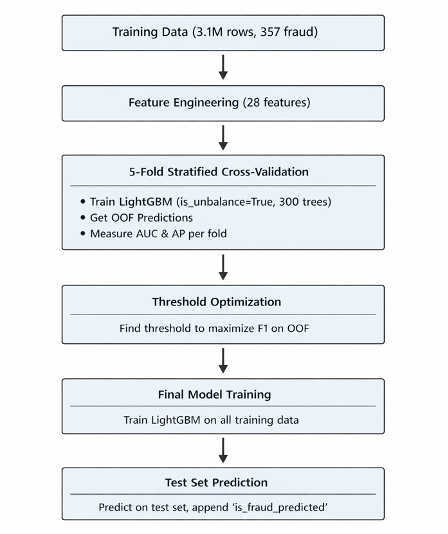

In [ ]:
# GENERATE TEST PREDICTIONS
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("PREDICTING ON TEST SET")
print("="*60)

test_proba = final_model.predict_proba(X_test.values)[:, 1]
test_preds = (test_proba >= best_threshold).astype(int)

test_out = test.copy()
test_out['is_fraud_predicted'] = test_preds
test_out.to_parquet(OUT_PATH, index=False)

print(f"  Predicted fraud: {test_preds.sum():,} / {len(test_preds):,} ({test_preds.mean()*100:.3f}%)")
print(f"  Saved to: {OUT_PATH}")
print(f"  Columns: {test_out.columns.tolist()}")

# ═══════════════════════════════════════════════════════════════════════════════
# EVALUATION PLOTS
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("EVALUATION PLOTS")
print("="*60)

# ── Plot 7: ROC + PR curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fpr, tpr, _ = roc_curve(y_train_arr, oof_proba)
axes[0].plot(fpr, tpr, color=PALETTE['fraud'], linewidth=2,
             label=f'LightGBM (AUC = {oof_auc:.4f})')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.12, color=PALETTE['fraud'])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (5-fold OOF)', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

axes[1].plot(recalls, precisions, color=PALETTE['fraud'], linewidth=2,
             label=f'LightGBM (AP = {oof_ap:.4f})')
axes[1].axvline(recalls[best_idx], color='gray', linestyle='--', linewidth=1)
axes[1].axhline(precisions[best_idx], color='gray', linestyle=':', linewidth=1)
axes[1].scatter(recalls[best_idx], precisions[best_idx], s=130, color='black', zorder=5,
                label=f'Optimal: P={precisions[best_idx]:.3f}, R={recalls[best_idx]:.3f}, F1={f1_scores[best_idx]:.3f}')
baseline_pr = y_train_arr.mean()
axes[1].axhline(baseline_pr, color='navy', linestyle='--', linewidth=1, alpha=0.5,
                label=f'Random baseline = {baseline_pr:.5f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (5-fold OOF)', fontweight='bold')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig(PLOT_DIR / "07_roc_pr_curves.png", bbox_inches='tight')
# plt.close()
# print("  Saved: 07_roc_pr_curves.png")

# ── Plot 8: Confusion matrix ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_train_arr, oof_preds)
ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraud']).plot(
    ax=axes[0], cmap='Blues', colorbar=True)
axes[0].set_title('Confusion Matrix — Raw Counts (OOF)', fontweight='bold')

cm_norm = confusion_matrix(y_train_arr, oof_preds, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=['Legitimate', 'Fraud']).plot(
    ax=axes[1], cmap='Blues', colorbar=True, values_format='.2%')
axes[1].set_title('Confusion Matrix — Normalized by True Class (OOF)', fontweight='bold')

plt.tight_layout()
plt.show()
plt.savefig(PLOT_DIR / "08_confusion_matrix.png", bbox_inches='tight')
# plt.close()
# print("  Saved: 08_confusion_matrix.png")

# ── Plot 9: Feature importance ────────────────────────────────────────────────
importance = pd.Series(final_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
top_n = importance.tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if i >= len(top_n)-5 else '#2980b9'
          for i in range(len(top_n))]
top_n.plot(kind='barh', ax=ax, color=colors, edgecolor='black', linewidth=0.4)
ax.set_title('Top 20 Feature Importances (LightGBM)', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()
plt.savefig(PLOT_DIR / "09_feature_importance.png", bbox_inches='tight')
# plt.close()
# print("  Saved: 09_feature_importance.png")

# ── Plot 10: Score distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_scores = oof_proba[y_train_arr == 1]
legit_scores = oof_proba[y_train_arr == 0]

axes[0].hist(legit_scores, bins=100, color=PALETTE['legit'], alpha=0.7,
             label='Legitimate', density=True)
axes[0].hist(fraud_scores, bins=30, color=PALETTE['fraud'], alpha=0.8,
             label='Fraud', density=True)
axes[0].axvline(best_threshold, color='black', linestyle='--', linewidth=2,
                label=f'Threshold = {best_threshold:.4f}')
axes[0].set_title('OOF Predicted Probability by True Class', fontweight='bold')
axes[0].set_xlabel('Predicted Fraud Probability')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_yscale('log')

# ── Plot 11: F1 / Precision / Recall vs threshold ────────────────────────────
axes[1].plot(thresholds, f1_scores[:-1], color=PALETTE['fraud'], linewidth=2, label='F1')
axes[1].plot(thresholds, precisions[:-1], color='green', linewidth=1.5, linestyle='--', label='Precision')
axes[1].plot(thresholds, recalls[:-1], color='orange', linewidth=1.5, linestyle='--', label='Recall')
axes[1].axvline(best_threshold, color='black', linestyle=':', linewidth=2,
                label=f'Optimal = {best_threshold:.4f}')
axes[1].set_xlabel('Classification Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision, Recall, F1 vs Threshold', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig(PLOT_DIR / "10_score_distribution_threshold.png", bbox_inches='tight')
# plt.close()
# print("  Saved: 10_score_distribution_threshold.png")

**Overall Model Performance — LightGBM**

* Recall: 99.7%
* Precision: 73%
* F1 Score: 0.843
* ROC-AUC: 1


We chose the model that prioritize recall because we would like to flag the suspicious transaction as much as possible.

In fraud detection the two types of errors have completely asymmetric costs:

    1. Missing 1 fraud (False Negative):
      → Customer loses ~$1.5M on average
      → Bank is liable and must reimburse
      → Regulatory scrutiny and potential fines
      → Permanent damage to customer trust
      → Reputational risk for Nasdaq

    2. Wrongly flagging 1 legit transaction (False Positive):
      → Analyst spends ~10 minutes reviewing
      → Customer briefly inconvenienced
      → Fully recoverable with an apology



Considering those 2 types of errors, from the business perspective, missing fraud is catastrophic. A false alarm is a minor operational cost. From this angel, we decided to maximize recall first and accept some false positives as an acceptable trade-off.

Look into the details of our data:

Specificity = 99.9958%

→ Only 1 in every 23,815 legitimate transactions is wrongly flagged

→ The vast majority of innocent customers are never affected


This is critical for a financial exchange like Nasdaq — customer experience for legitimate transactions must be protected.




We chose different evaluation metric for the model.

ROC-AUC. vs. PR

It's a curve that shows the trade-off between catching fraud and accidentally flagging legit transactions at every possible threshold.

*Y-axis: True positive rate = recall*

  it showed us of all the real faud, how much did the model catch?

*X-axis: False posible rate*

It showed that of all legit transactions, how many did we wrongly flag?







Also note, since the model is highly imbalanced, ROC-AUC along is not the perfect evaluation method. But it can still shows us the top left corner (0, 1) = perfect model. It catches all fraud, zero false alarms.

That sounds perfect, and it is in terms of ranking. But for imbalanced problems like fraud detection, combineing PR-AUC (Average Precision) = 0.68, it tells the more honest storyboth together!

ROC-AUC tells you the model can rank, PR-AUC tells you if it can actually be precise when deployed.

therefore, we decided on doing a precision_recall curve to find the perfect threshold.


**Here is a snippet of what the code actually does:**

1. Generate precision, recall, threshold for every possible cutoff

    `precisions, recalls, thresholds = precision_recall_curve(y_train, oof_proba)`

2. Compute F1 at every threshold

    `f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)`

3. Filter to operationally viable thresholds only

    `valid_mask = (recalls[:-1] >= 0.5) & (precisions[:-1] >= 0.05)`

4. Among valid ones, find the threshold with **highest F1**

    `best_idx = np.where(valid_mask)[0][np.argmax(f1_scores[:-1][valid_mask])]`

    `best_threshold = thresholds[best_idx]`


**Our choice:**

**Threshold 0.9998 → Precision=73%,    Recall=99.7% F1 = 0.843**

**We would only miss one fraud transaction among 357, and have 132 false alarm per month(4.3/day) as a trade off**

**The value at risk(1 missed) is about \$1.5M, but we protected 356 × \$1,523,691(average fraud transaction) ≈ $542M**

Note:

We maximized F1 as the default, but in production the optimal threshold should be determined by the business — specifically the ratio of the cost of missing fraud versus the cost of investigating a false alarm.

If each missed fraud costs \$1.5M and each false alarm costs $50 in analyst time, the math strongly favours a lower threshold and higher recal




    One example:

    If catching every single fraud is paramount (zero tolerance):

      * Lower the threshold
      * Recall → 100%  but  Precision drops to ~50%
      * More false alarms, higher analyst workload

    If analyst capacity is limited:
      * Raise the threshold
      * Precision → 90%+  but  Recall drops to ~85%
      * Fewer alerts but miss more fraud

    Our choice (maximize F1):
      * Best mathematical balance between the two
      * Most appropriate when costs of both errors are considered together




## **Stage 2: From Classification to Cost-Sensitive Learning(Regression)**

The original model treated every fraud case equally. Missing a \$119 fraud and missing a $10M fraud were penalized the same. However, that could be misaligned from a business perspective.

Rather than treating all fraud transactions equally, we weighted the loss function by transaction amount — so the model is penalized proportionally to the financial risk of each missed case.

We then replaced F1 optimization with a business cost function that explicitly models the trade-off between missed fraud value and analyst investigation costs.




**Version 1**

    base_w   = legit_n / fraud_n   ≈ 8,806

    weight(legit transaction)    = 1.0  (unchanged)

    weight(fraud transaction)    = base_imbalance_correction × amount_importance
                                 = 8,806 × (transaction_amount / mean_fraud_amount)

    Example:
      $119 fraud    →  weight = 8,806 × 0.00008  =      0.7   (nearly ignored)
      $1.5M fraud   →  weight = 8,806 × 1.0      =  8,806     (average)
      $10M fraud    →  weight = 8,806 × 6.6      = 57,794     (6.6× more important)


In this option, we weight each fraud proportionally to how large it is relative to the average fraud.

This tells the lightGBM model the cost of missing this transaction equals its dollar value. And it's loss fucntion now directly reflects financial risk.

Instead of maximizing F1, we define what the real-world cost is at every possible threshold:

    Total Cost = Fraud Cost + Operational Cost

    Fraud Cost  = Σ(dollar amounts of all missed fraud transactions)
                = "how much money slipped through?"

    Ops Cost    = Number of false alarms × cost per investigation
                = "how much analyst time did we waste?"




We also created three scenarios for costs per alert were tested:

Cost/Alert csost/ Represents:
\$50	for Junior analyst, quick review

\$200 for 	Senior analyst, thorough investigation

\$500	Full compliance team review

With all the assumptions and loss functions we have, now we can find the optimal threshold that gives us the minimum total cost


In [ ]:
"""
Fraud Detection — Amount-Weighted Model (Version 1)
=====================================================
Weight formula:
    weight(legit)  = 1.0
    weight(fraud)  = base_w × (amount / mean_fraud_amount)

This is the ORIGINAL version before the floor correction.
The idea is to scale each fraud's importance by its dollar value relative
to the average fraud amount:
  - A fraud worth 2× the average gets 2× the class-imbalance weight
  - A fraud worth 0.5× the average gets 0.5× the class-imbalance weight

Known limitation of this formula:
  - Small-value fraud (< mean_amount) gets weight < base_w
  - Tiny frauds (e.g. $119) can get weight < 1.0 — LESS than a legit transaction


"""

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix)
import lightgbm as lgb

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE     = Path("/content/Nasdaq")
TRAIN    = BASE / "train_fraud.parquet"
TEST     = BASE / "test_fraud_external.parquet"
OUT      = BASE / "test_fraud_external_predicted_v1.parquet"
PLOT_DIR = BASE / "plots"
PLOT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})
FRAUD_COLOR = '#e74c3c'
OPS_COLOR   = '#2980b9'
TOTAL_COLOR = '#2c3e50'
OPT_COLOR   = '#f39c12'

# ═══════════════════════════════════════════════════════════════════════════════
# 1. LOAD
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("1. LOADING DATA")
print("="*60)

train = pd.read_parquet(TRAIN)
test  = pd.read_parquet(TEST)
print(f"Train: {train.shape}  |  Test: {test.shape}")
print(f"Fraud rate: {train['is_fraud'].mean()*100:.4f}%  ({train['is_fraud'].sum()} cases)")

TYPE_MAP = {t: i for i, t in enumerate(sorted(
    pd.concat([train['transaction_type'], test['transaction_type']]).unique()
))}

# ═══════════════════════════════════════════════════════════════════════════════
# 2. FEATURE ENGINEERING
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("2. FEATURE ENGINEERING")
print("="*60)

def engineer_features(df):
    df = df.copy()

    # Log-transformed amounts and balances
    df['log_amount']            = np.log1p(df['transaction_amount'])
    df['log_init_bal_before']   = np.log1p(df['initiater_balance_before'].clip(lower=0))
    df['log_recip_bal_before']  = np.log1p(df['recipient_balance_before'].clip(lower=0))
    df['log_init_bal_after']    = np.log1p(df['initiater_balance_after'].clip(lower=0))
    df['log_recip_bal_after']   = np.log1p(df['recipient_balance_after'].clip(lower=0))

    # Balance changes
    df['init_balance_change']   = df['initiater_balance_before'] - df['initiater_balance_after']
    df['recip_balance_change']  = df['recipient_balance_after']  - df['recipient_balance_before']
    df['log_init_bal_change']   = np.log1p(df['init_balance_change'].clip(lower=0))
    df['log_recip_bal_change']  = np.log1p(df['recip_balance_change'].clip(lower=0))

    # Balance anomalies
    df['init_amount_mismatch']  = (np.abs(df['init_balance_change'] - df['transaction_amount']) > 1.0).astype(int)
    df['recip_amount_mismatch'] = (np.abs(df['recip_balance_change'] - df['transaction_amount']) > 1.0).astype(int)

    # Account drain signals
    df['drains_account']        = (
        (df['initiater_balance_before'] > 0) &
        (np.abs(df['transaction_amount'] - df['initiater_balance_before']) < 1.0)
    ).astype(int)
    df['init_became_zero']      = (
        (df['initiater_balance_before'] > 0) & (df['initiater_balance_after'] == 0)
    ).astype(int)
    df['recip_became_zero']     = (
        (df['recipient_balance_before'] > 0) & (df['recipient_balance_after'] == 0)
    ).astype(int)

    # Zero balance flags
    df['init_zero_before']      = (df['initiater_balance_before'] == 0).astype(int)
    df['recip_zero_before']     = (df['recipient_balance_before'] == 0).astype(int)

    # Amount ratios
    df['amount_to_init_ratio']  = df['transaction_amount'] / (df['initiater_balance_before'] + 1)
    df['amount_to_recip_ratio'] = df['transaction_amount'] / (df['recipient_balance_before'] + 1)

    # Entity type
    df['initiator_is_customer'] = (df['initiating_customer'].str[0] == 'C').astype(int)
    df['recipient_is_customer'] = (df['recipient_customer'].str[0]  == 'C').astype(int)
    df['c2c'] = ((df['initiator_is_customer']==1) & (df['recipient_is_customer']==1)).astype(int)
    df['c2m'] = ((df['initiator_is_customer']==1) & (df['recipient_is_customer']==0)).astype(int)

    # Time features
    df['hour_of_day']  = df['hours_elapsed'] % 24
    df['day_of_month'] = df['hours_elapsed'] // 24
    df['is_night']     = ((df['hour_of_day'] >= 22) | (df['hour_of_day'] < 6)).astype(int)

    # Transaction type
    df['txn_type_enc'] = df['transaction_type'].map(TYPE_MAP).fillna(-1).astype(int)
    df['is_cash_out']  = (df['transaction_type'] == 'CASH_OUT').astype(int)
    df['is_transfer']  = (df['transaction_type'] == 'TRANSFER').astype(int)

    return df

FEATURES = [
    'log_amount', 'amount_to_init_ratio', 'amount_to_recip_ratio',
    'log_init_bal_before', 'log_recip_bal_before',
    'log_init_bal_after', 'log_recip_bal_after',
    'log_init_bal_change', 'log_recip_bal_change',
    'init_amount_mismatch', 'recip_amount_mismatch',
    'drains_account', 'init_became_zero', 'recip_became_zero',
    'init_zero_before', 'recip_zero_before',
    'initiator_is_customer', 'recipient_is_customer', 'c2c', 'c2m',
    'hour_of_day', 'day_of_month', 'is_night',
    'txn_type_enc', 'is_cash_out', 'is_transfer',
    'is_flagged_fraud', 'hours_elapsed',
]

train_fe = engineer_features(train)
test_fe  = engineer_features(test)
X        = train_fe[FEATURES].values
y        = train_fe['is_fraud'].values
amounts  = train['transaction_amount'].values

print(f"Features: {len(FEATURES)}  |  X_train: {X.shape}  |  X_test: {test_fe[FEATURES].shape}")

# ═══════════════════════════════════════════════════════════════════════════════
# 3. ORIGINAL AMOUNT-WEIGHTED SAMPLE WEIGHTS  (no floor)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("3. SAMPLE WEIGHT CONSTRUCTION  (v1 — proportional, no floor)")
print("="*60)

legit_n           = int((y == 0).sum())
fraud_n           = int((y == 1).sum())
base_w            = legit_n / fraud_n          # class imbalance ratio ~8,806
fraud_amounts     = amounts[y == 1]
mean_fraud_amount = fraud_amounts.mean()

# ── ORIGINAL FORMULA ──────────────────────────────────────────────────────────
#
#   weight(legit)  = 1.0
#   weight(fraud)  = base_w × (amount / mean_fraud_amount)
#
# Rationale:
#   - base_w corrects for class imbalance (357 fraud vs 3.1M legit)
#   - (amount / mean) scales each fraud case by its relative dollar importance:
#       • A $3M fraud (2× mean ~$1.5M) gets weight = base_w × 2 = 17,612
#       • A $1.5M fraud (1× mean)      gets weight = base_w × 1 = 8,806
#       • A $750K fraud (0.5× mean)    gets weight = base_w × 0.5 = 4,403
#       • A $119 fraud (0.00008× mean) gets weight = base_w × 0.00008 ≈ 0.69  ← BUG
#
# The bug: small frauds get weight < 1, meaning the model treats them as
# LESS important than an ordinary legitimate transaction.
# See fraud_model_weighted.py (v2) for the fix.
# ─────────────────────────────────────────────────────────────────────────────
sample_weights          = np.ones(len(y))
sample_weights[y == 1]  = base_w * (fraud_amounts / mean_fraud_amount)

w_fraud = sample_weights[y == 1]
print(f"Legit weight             : 1.0  (all identical)")
print(f"Class imbalance ratio    : {base_w:.0f}  (base_w = legit_n / fraud_n)")
print(f"Mean fraud amount        : ${mean_fraud_amount:,.0f}")
print(f"Fraud weight min         : {w_fraud.min():.4f}  ← may be < 1.0!")
print(f"Fraud weight mean        : {w_fraud.mean():.0f}")
print(f"Fraud weight max         : {w_fraud.max():.0f}")
print(f"Fraud cases with weight < 1.0 : {(w_fraud < 1.0).sum()}  "
      f"({'!some fraud treated as less important than legit' if (w_fraud < 1.0).any() else '✅ none'})")
print(f"\nWeight examples:")
print(f"  $119 fraud   → weight {base_w*(119/mean_fraud_amount):>10.2f}"
      f"  {'!< 1.0 (less than legit!)' if base_w*(119/mean_fraud_amount) < 1 else ''}")
print(f"  $1.5M fraud  → weight {base_w*(1.5e6/mean_fraud_amount):>10.0f}")
print(f"  $10M fraud   → weight {base_w*(10e6/mean_fraud_amount):>10.0f}")

# ═══════════════════════════════════════════════════════════════════════════════
# 4. MODEL TRAINING — LightGBM with amount-weighted loss
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("4. MODEL TRAINING")
print("="*60)

lgb_params = dict(
    objective         = 'binary',
    metric            = 'auc',
    boosting_type     = 'gbdt',
    n_estimators      = 300,
    learning_rate     = 0.05,
    num_leaves        = 63,
    max_depth         = 6,
    min_child_samples = 2,
    feature_fraction  = 0.8,
    bagging_fraction  = 0.8,
    bagging_freq      = 5,
    lambda_l1         = 1.0,
    lambda_l2         = 1.0,
    # Note: NOT using is_unbalance=True — sample_weight handles class imbalance
    random_state      = 42,
    verbose           = -1,
    n_jobs            = -1,
)

cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_proba = np.zeros(len(X))
fold_aucs = []
fold_aps  = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y)):
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X[tr_idx], y[tr_idx],
        sample_weight=sample_weights[tr_idx]
    )
    proba = model.predict_proba(X[va_idx])[:, 1]
    oof_proba[va_idx] = proba

    auc = roc_auc_score(y[va_idx], proba)
    ap  = average_precision_score(y[va_idx], proba)
    fold_aucs.append(auc)
    fold_aps.append(ap)
    print(f"  Fold {fold+1}: AUC={auc:.4f}  AP={ap:.4f}")

oof_auc = roc_auc_score(y, oof_proba)
oof_ap  = average_precision_score(y, oof_proba)
print(f"\n  OOF ROC-AUC         : {oof_auc:.4f}")
print(f"  OOF Avg Precision   : {oof_ap:.4f}")

# Train final model on all training data
print("\n  Training final model on full dataset...")
final_model = lgb.LGBMClassifier(**lgb_params)
final_model.fit(X, y, sample_weight=sample_weights)
print("  Done.")

# ═══════════════════════════════════════════════════════════════════════════════
# 5. THRESHOLD — F1 maximisation with recall >= 0.5, precision >= 0.05
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("5. THRESHOLD OPTIMIzATION")
print("="*60)

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y, oof_proba)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)

valid_mask = (recalls[:-1] >= 0.5) & (precisions[:-1] >= 0.05)
if valid_mask.any():
    best_idx       = np.where(valid_mask)[0][np.argmax(f1_scores[:-1][valid_mask])]
    best_threshold = float(thresholds[best_idx])
    best_precision = float(precisions[best_idx])
    best_recall    = float(recalls[best_idx])
    best_f1        = float(f1_scores[best_idx])
else:
    best_idx       = np.argmax(f1_scores[:-1])
    best_threshold = float(thresholds[best_idx])
    best_precision = float(precisions[best_idx])
    best_recall    = float(recalls[best_idx])
    best_f1        = float(f1_scores[best_idx])

oof_preds = (oof_proba >= best_threshold).astype(int)
cm        = confusion_matrix(y, oof_preds)
tn, fp_val, fn_val, tp_val = cm.ravel()

print(f"  Best threshold : {best_threshold:.6f}")
print(f"  Precision      : {best_precision*100:.1f}%")
print(f"  Recall         : {best_recall*100:.1f}%")
print(f"  F1             : {best_f1:.4f}")
print(f"  TP={tp_val}  FP={fp_val}  FN={fn_val}  TN={tn}")

# ═══════════════════════════════════════════════════════════════════════════════
# 6. TEST SET PREDICTIONS
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("6. TEST SET PREDICTIONS")
print("="*60)

test_proba = final_model.predict_proba(test_fe[FEATURES].values)[:, 1]
test_preds = (test_proba >= best_threshold).astype(int)

test_out = test.copy()
test_out['is_fraud_predicted'] = test_preds
test_out.to_parquet(OUT, index=False)

print(f"  Threshold (F1-opt)   : {best_threshold:.6f}")
print(f"  Predicted fraud      : {test_preds.sum():,} / {len(test_preds):,} ({test_preds.mean()*100:.3f}%)")
print(f"  Saved to             : {OUT}")

# ═══════════════════════════════════════════════════════════════════════════════
# 7. PLOTS — Weight distribution + PR curve
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("7. GENERATING PLOTS")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Amount-Weighted Fraud Model — v1 (Proportional, No Floor)',
             fontsize=13, fontweight='bold')

# ── Plot A: Weight formula visualized ─────────────────────────────────────────
ax = axes[0]
sort_idx = np.argsort(fraud_amounts)
ax.plot(fraud_amounts[sort_idx] / 1e6,
        base_w * (fraud_amounts[sort_idx] / mean_fraud_amount),
        color=FRAUD_COLOR, linewidth=2.5,
        label='v1 formula: base_w × (amount / mean)')
ax.axhline(1.0,   color='black',  linewidth=1.2, linestyle=':',  label='Legit weight = 1.0')
ax.axhline(base_w, color='navy',  linewidth=1.2, linestyle='--', label=f'base_w = {base_w:.0f}')
ax.fill_between(fraud_amounts[sort_idx] / 1e6, 0, 1,
                color='red', alpha=0.12, label='DANGER ZONE: fraud < legit')

broken_mask = (base_w * (fraud_amounts / mean_fraud_amount)) < 1.0
if broken_mask.any():
    ax.scatter(fraud_amounts[broken_mask] / 1e6,
               base_w * (fraud_amounts[broken_mask] / mean_fraud_amount),
               color='red', s=80, zorder=6,
               label=f'{broken_mask.sum()} fraud cases with weight < 1')

ax.set_title('v1 Weight Formula\nbase_w × (amount / mean)', fontweight='bold')
ax.set_xlabel('Fraud Transaction Amount ($M)')
ax.set_ylabel('Sample Weight')
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.3)

# ── Plot B: Precision-Recall curve ────────────────────────────────────────────
ax = axes[1]
ax.plot(recalls, precisions, color=FRAUD_COLOR, linewidth=2,
        label=f'PR curve  (AP = {oof_ap:.4f})')
ax.scatter([best_recall], [best_precision], s=200, color=OPT_COLOR,
           zorder=5, edgecolor='black', linewidth=1.5,
           label=f'Optimal point\n(thr={best_threshold:.4f})')
ax.annotate(
    f"P={best_precision*100:.1f}%\nR={best_recall*100:.1f}%\nF1={best_f1:.3f}",
    xy=(best_recall, best_precision),
    # textcoords='axes fraction',
    xytext=(best_recall - 0.25, best_precision - 0.2),
    fontsize=9, arrowprops=dict(arrowstyle='->', color='black'),
    bbox=dict(boxstyle='round', facecolor='#fff9e6', edgecolor=OPT_COLOR, alpha=0.9)
)
ax.set_title('Precision-Recall Curve\n(F1-optimal threshold)', fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.05)

# ── Plot C: Confusion matrix ───────────────────────────────────────────────────
ax = axes[2]
cm_display = np.array([[tn, fp_val], [fn_val, tp_val]])
im = ax.imshow(cm_display, cmap='Blues')
plt.colorbar(im, ax=ax)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm_display[i, j]:,}', ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if cm_display[i, j] > cm_display.max() / 2 else 'black')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred: Legit', 'Pred: Fraud'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Actual: Legit', 'Actual: Fraud'])
ax.set_title(f'OOF Confusion Matrix\n(threshold = {best_threshold:.4f})', fontweight='bold')

plt.tight_layout()
plt.show()
# plt.savefig(PLOT_DIR / '12b_weighted_v1.png', bbox_inches='tight')
# plt.close()
# print("  Saved: plots/12b_weighted_v1.png")

# ═══════════════════════════════════════════════════════════════════════════════
# 8. FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("FINAL SUMMARY  (v1 — proportional weights, no floor)")
print("="*60)
print(f"\nWeight formula    : base_w × (amount / mean_amount)")
print(f"Base_w            : {base_w:.0f}")
print(f"Mean fraud amount : ${mean_fraud_amount:,.0f}")
print(f"Weight range      : {w_fraud.min():.2f} – {w_fraud.max():,.0f}")
print(f"Fraud < legit wt  : {(w_fraud < 1.0).sum()} cases  ({'known limitation' if (w_fraud < 1.0).any() else 'none'})")
print(f"\nOOF Performance:")
print(f"  ROC-AUC         : {oof_auc:.4f}")
print(f"  Avg Precision   : {oof_ap:.4f}")
print(f"  Threshold       : {best_threshold:.6f}")
print(f"  Recall          : {best_recall*100:.1f}%")
print(f"  Precision       : {best_precision*100:.1f}%")
print(f"  F1              : {best_f1:.4f}")
print(f"  TP={tp_val}  FP={fp_val}  FN={fn_val}")
print(f"\nTest predictions  : {test_preds.sum():,} fraud / {len(test_preds):,} total")
print(f"Output saved to   : {OUT}")
print(f"Plot saved to     : {PLOT_DIR}/12b_weighted_v1.png")
print("\n" + "="*60)
print("DONE")
print("="*60)
print("\n NOTE: For the corrected formula (floor fix), see fraud_model_weighted.py")



Overall:
|  | Baseline Model | Weighted Model |
|---|---|---|
| Recall| 99.7%	 | 98.9% |
| Precision| 73.0% | 99.7% |
| Fraud missed| 1 | 4|
| Ops cost/month| \$26,400 | \$200|
| Total cost/month| \$1.5M + $26K| \$399K|

From the new approach, at $200 per alert, the optimal threshold of 0.997 gives 98.9% recall with 99.7% precision. Just 1 false alarm per month. We did sacrifice a little bit recall, but we get an increased precision rate, and a tremendous cost saving!  

This new weighted model focuses on protecting the highest-value fraud cases first, which is aligns with many companies' priority,especially for financial institution, where a single missed transaction can represent millions of dollars in liability.



**Version 2: Conservative approach**

There are many institutions have High-value transaction businesses. Such as inverstment banking, prime brokerage,and real estate, etc. For those company, where one fraud transaction would leads to 10+ millions loss. Then treating all fraud equally would be not accurate.

Therefore, therefore, our cost function need to change.

In the below model, we applied a floor(+1) to the original weighted model.


```
weight(fraud) = base_w × (1 + amount / mean_amount)
```

+1 acts as a guaranteed floor to make sure all fraud transcation, regardless the amount, it should weight more than the legit transaction (legit transaction weight =1 ).

The 1 says: "every single fraud counts as 8,806 legitimate transactions regardless of amount."





In [ ]:
# 2nd VERSION: AMOUNT-WEIGHTED SAMPLE WEIGHTS
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("SAMPLE WEIGHT CONSTRUCTION -2nd VERSION")
print("="*60)

legit_n           = int((y == 0).sum())
fraud_n           = int((y == 1).sum())
base_w            = legit_n / fraud_n          # class imbalance ratio ~8,806
fraud_amounts     = amounts[y == 1]
mean_fraud_amount = fraud_amounts.mean()

# ── CORRECTED FORMULA ─────────────────────────────────────────────────────────
#
#   weight(legit)  = 1.0
#   weight(fraud)  = base_w × (1 + amount / mean_fraud_amount)
#
# The "+1" is the critical fix:
#   - Guarantees every fraud weight >= base_w (floor = 8,806)
#   - A $0 fraud still counts as 8,806 legit transactions
#   - Higher-value fraud gets proportionally MORE weight on top
#   - No fraud case can EVER be weighted below a legit transaction
#
# Why not just use base_w × (amount/mean)?
#   That formula divides by mean_amount, so anything below average gets
#   weight < base_w, and tiny frauds ($119) get weight < 1 — less important
#   than a legitimate transaction. That is fundamentally wrong.
# ─────────────────────────────────────────────────────────────────────────────
sample_weights          = np.ones(len(y))
sample_weights[y == 1]  = base_w * (1 + fraud_amounts / mean_fraud_amount)

w_fraud = sample_weights[y == 1]
print(f"Legit weight          : 1.0  (all identical)")
print(f"Fraud weight floor    : {base_w * 1:.0f}  (any fraud, even $0)")
print(f"Fraud weight mean     : {w_fraud.mean():.0f}  (average-value fraud)")
print(f"Fraud weight max      : {w_fraud.max():.0f}  ($10M fraud)")
print(f"Any fraud weight < 1? : {(w_fraud < 1.0).any()}  ")
print(f"Any fraud weight < base_w? : {(w_fraud < base_w).any()}  ")
print(f"\nInterpretation:")
print(f"  $119 fraud   → weight {base_w*(1+119/mean_fraud_amount):>8,.0f}"
      f"  ({base_w*(1+119/mean_fraud_amount):.0f}× more than legit)")
print(f"  $1.5M fraud  → weight {base_w*(1+1):>8,.0f}"
      f"  ({base_w*(1+1):.0f}× more than legit)")
print(f"  $10M fraud   → weight {base_w*(1+10e6/mean_fraud_amount):>8,.0f}"
      f"  ({base_w*(1+10e6/mean_fraud_amount):.0f}× more than legit)")

# ═══════════════════════════════════════════════════════════════════════════════
#  MODEL TRAINING — LightGBM with amount-weighted loss
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print(" MODEL TRAINING")
print("="*60)

lgb_params = dict(
    objective         = 'binary',
    metric            = 'auc',
    boosting_type     = 'gbdt',
    n_estimators      = 300,
    learning_rate     = 0.05,
    num_leaves        = 63,
    max_depth         = 6,
    min_child_samples = 2,
    feature_fraction  = 0.8,
    bagging_fraction  = 0.8,
    bagging_freq      = 5,
    lambda_l1         = 1.0,
    lambda_l2         = 1.0,
    # Note: NOT using is_unbalance=True here because sample_weight
    # already encodes the class imbalance correction (base_w factor)
    random_state      = 42,
    verbose           = -1,
    n_jobs            = -1,
)

cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_proba = np.zeros(len(X))
fold_aucs = []
fold_aps  = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y)):
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X[tr_idx], y[tr_idx],
        sample_weight=sample_weights[tr_idx]
    )
    proba = model.predict_proba(X[va_idx])[:, 1]
    oof_proba[va_idx] = proba

    auc = roc_auc_score(y[va_idx], proba)
    ap  = average_precision_score(y[va_idx], proba)
    fold_aucs.append(auc)
    fold_aps.append(ap)
    print(f"  Fold {fold+1}: AUC={auc:.4f}  AP={ap:.4f}")

oof_auc = roc_auc_score(y, oof_proba)
oof_ap  = average_precision_score(y, oof_proba)
print(f"\n  OOF ROC-AUC         : {oof_auc:.4f}")
print(f"  OOF Avg Precision   : {oof_ap:.4f}")

# Train final model on all training data
print("\n  Training final model on full dataset...")
final_model = lgb.LGBMClassifier(**lgb_params)
final_model.fit(X, y, sample_weight=sample_weights)
print("  Done.")

# ═══════════════════════════════════════════════════════════════════════════════
# COST-SENSITIVE THRESHOLD OPTIMIZATION
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("COST-SENSITIVE THRESHOLD OPTIMIZATION")
print("="*60)

# Cost function:
#   Total Cost = Fraud Cost + Operational Cost
#
#   Fraud Cost     = sum of dollar amounts of all MISSED fraud transactions
#                  = "how much money slipped through undetected?"
#
#   Operational    = number of false alarms × cost per investigation
#                  = "how much analyst time did we waste?"
#
# We test 3 cost-per-alert scenarios to show sensitivity

thresholds_sweep    = np.linspace(0.0001, 0.9999, 3000)
cost_scenarios      = [50, 200, 500]

results = {}
for cpa in cost_scenarios:
    fc, oc, tc, rec_l, prec_l, fp_l, fn_l = [], [], [], [], [], [], []

    for thr in thresholds_sweep:
        preds = (oof_proba >= thr).astype(int)
        tp = int(((preds==1) & (y==1)).sum())
        fp = int(((preds==1) & (y==0)).sum())
        fn = int(((preds==0) & (y==1)).sum())

        # Dollar value of fraud that slipped through
        missed_val = fraud_amounts[(preds[y==1] == 0)].sum()

        fc.append(missed_val)
        oc.append(fp * cpa)
        tc.append(missed_val + fp * cpa)
        fp_l.append(fp)
        fn_l.append(fn)
        rec_l.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        prec_l.append(tp / (tp + fp) if (tp + fp) > 0 else 0)

    results[cpa] = dict(
        fc=np.array(fc), oc=np.array(oc), tc=np.array(tc),
        rec=np.array(rec_l), prec=np.array(prec_l),
        fp=np.array(fp_l), fn=np.array(fn_l)
    )

    opt     = int(np.argmin(tc))
    opt_thr = thresholds_sweep[opt]
    print(f"\n  Cost per alert = ${cpa}")
    print(f"    Optimal threshold : {opt_thr:.6f}")
    print(f"    Recall            : {rec_l[opt]*100:.1f}%")
    print(f"    Precision         : {prec_l[opt]*100:.1f}%")
    print(f"    False alarms/month: {fp_l[opt]}")
    print(f"    Fraud missed      : {fn_l[opt]}")
    print(f"    Fraud cost        : ${fc[opt]:,.0f}")
    print(f"    Ops cost          : ${oc[opt]:,.0f}")
    print(f"    Total cost        : ${tc[opt]:,.0f}")

# ═══════════════════════════════════════════════════════════════════════════════
# GENERATE TEST PREDICTIONS (using $200/alert optimal threshold)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("TEST SET PREDICTIONS")
print("="*60)

opt_thr    = thresholds_sweep[int(np.argmin(results[200]['tc']))]
test_proba = final_model.predict_proba(test_fe[FEATURES].values)[:, 1]
test_preds = (test_proba >= opt_thr).astype(int)

test_out = test.copy()
test_out['is_fraud_predicted'] = test_preds
test_out.to_parquet(OUT, index=False)

print(f"  Optimal threshold (${200}/alert): {opt_thr:.6f}")
print(f"  Predicted fraud  : {test_preds.sum():,} / {len(test_preds):,} ({test_preds.mean()*100:.3f}%)")
# print(f"  Saved to         : {OUT}")



# ═══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════
opt_res = results[200]
opt_idx = int(np.argmin(opt_res['tc']))

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"\nWeight formula    : base_w × (1 + amount/mean_amount)")
print(f"Weight floor      : {base_w:.0f}  (every fraud always >> legit)")
print(f"Threshold (opt)   : {thresholds_sweep[opt_idx]:.6f}  ($200/alert scenario)")
print(f"\nOOF Performance:")
print(f"  ROC-AUC         : {oof_auc:.4f}")
print(f"  Avg Precision   : {oof_ap:.4f}")
print(f"  Recall          : {opt_res['rec'][opt_idx]*100:.1f}%")
print(f"  Precision       : {opt_res['prec'][opt_idx]*100:.1f}%")
print(f"  False alarms/mo : {opt_res['fp'][opt_idx]}")
print(f"  Fraud missed    : {opt_res['fn'][opt_idx]}")
print(f"  Total cost/mo   : ${opt_res['tc'][opt_idx]:,.0f}")
print(f"\nTest predictions  : {test_preds.sum():,} fraud / {len(test_preds):,} total")
print(f"Output saved to   : {OUT}")
# print(f"Plot saved to     : {PLOT_DIR}/12_cost_optimization.png")
print("\n" + "="*60)
print("DONE")
print("="*60)


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib
matplotlib.use('inline')   # reset to interactive
import matplotlib.pyplot as plt
%matplotlib inline

# ── Base params (no is_unbalance, no weights = original behaviour) ────────────
base_params = dict(
    objective='binary', metric='auc', boosting_type='gbdt',
    n_estimators=300, learning_rate=0.05, num_leaves=63, max_depth=6,
    min_child_samples=2, feature_fraction=0.8, bagging_fraction=0.8,
    bagging_freq=5, lambda_l1=1.0, lambda_l2=1.0,
    is_unbalance=True, random_state=42, verbose=-1, n_jobs=-1,
)
weighted_params = {**base_params, 'is_unbalance': False}

TARGET = 'is_fraud'
X_train = train_fe[FEATURES]
y_train = train_fe[TARGET]
X_test  = test_fe[FEATURES]


X_train_arr = X_train.values
y_train_arr = y_train.values
amounts           = train['transaction_amount'].values
fraud_n           = int((y_train_arr == 1).sum())
legit_n           = int((y_train_arr == 0).sum())
base_w            = legit_n / fraud_n
fraud_amounts     = amounts[y_train_arr == 1]
mean_fraud_amount = fraud_amounts.mean()

# ── 3 weight schemes ──────────────────────────────────────────────────────────
weights_no_floor  = np.ones(len(y_train_arr))
weights_no_floor[y_train_arr == 1]  = base_w * (fraud_amounts / mean_fraud_amount)

weights_with_floor = np.ones(len(y_train_arr))
weights_with_floor[y_train_arr == 1] = base_w * (1 + fraud_amounts / mean_fraud_amount)

models = [
    ('Original (is_unbalance)',  base_params,     None),
    ('Weighted, no floor',       weighted_params, weights_no_floor),
    ('Weighted, with floor',     weighted_params, weights_with_floor),
]

# ── Run CV for each model ─────────────────────────────────────────────────────
results = {}
for name, params, weights in models:
    oof = np.zeros(len(y_train_arr))
    for tr_idx, va_idx in cv.split(X_train_arr, y_train_arr):
        X_tr, y_tr = X_train_arr[tr_idx], y_train_arr[tr_idx]
        X_va       = X_train_arr[va_idx]
        w_tr       = weights[tr_idx] if weights is not None else None
        m = lgb.LGBMClassifier(**params)
        m.fit(X_tr, y_tr, sample_weight=w_tr)
        oof[va_idx] = m.predict_proba(X_va)[:, 1]
    results[name] = oof

# ── Plot PR curves ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'orange', 'green']

for (name, oof), color in zip(results.items(), colors):
    p, r, _ = precision_recall_curve(y_train_arr, oof)
    ap = average_precision_score(y_train_arr, oof)
    ax.plot(r, p, label=f'{name}  (AP={ap:.4f})', color=color, lw=2)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — 3 Models')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('plots/pr_curve_comparison.png', dpi=150)
plt.show()



**Blue (Original, AP=0.6837)** — looks like a normal PR curve

Precision degrades steadily as recall increases
This is what a "normal" imperfect model looks like

**Orange (no floor, AP=0.9928)** — vertical drop at recall=1.0

The model maintains high precision all the way to ~recall=0.97
Only when you force it to catch the very last few frauds (recall→1.0) does precision suddenly collapse

The "curve" is so compressed into the top-right corner it looks like a vertical line

**Green (with floor, AP=1.0000)** — flat line at precision=1.0

Perfect classifier — catches all fraud with zero false positives at the optimal threshold

The curve is literally a horizontal line at y=1.0, then a vertical drop
This is what AP=1.0 looks like by definition

## **Stage 3: Validation on ensemabled model**

Xgboost, Random Forest


In [ ]:
"""
Fraud Detection — XGBoost Cost-Sensitive Weighted Model
========================================================
Same methodology as fraud_model_weighted.py but using XGBoost instead of LightGBM.

LightGBM → XGBoost parameter mapping:
  num_leaves=63        → (no direct equiv; max_depth=6 gives ~63 leaves)
  min_child_samples=2  → min_child_weight=1
  feature_fraction=0.8 → colsample_bytree=0.8
  bagging_fraction=0.8 → subsample=0.8
  bagging_freq=5       → (XGBoost subsamples every tree by default)
  lambda_l1=1.0        → reg_alpha=1.0
  lambda_l2=1.0        → reg_lambda=1.0
  verbose=-1           → verbosity=0
  metric='auc'         → eval_metric='auc'
  objective='binary'   → objective='binary:logistic'
"""

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix)
import xgboost as xgb

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE     = Path("/content/Nasdaq")
TRAIN    = BASE / "train_fraud.parquet"
TEST     = BASE / "test_fraud_external.parquet"
OUT      = BASE / "test_fraud_external_predicted_xgb.parquet"
PLOT_DIR = BASE / "plots"
PLOT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})
FRAUD_COLOR = '#e74c3c'
OPS_COLOR   = '#2980b9'
TOTAL_COLOR = '#2c3e50'
OPT_COLOR   = '#f39c12'

# ═══════════════════════════════════════════════════════════════════════════════
# 1. LOAD
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("1. LOADING DATA")
print("="*60)

train = pd.read_parquet(TRAIN)
test  = pd.read_parquet(TEST)
print(f"Train: {train.shape}  |  Test: {test.shape}")
print(f"Fraud rate: {train['is_fraud'].mean()*100:.4f}%  ({train['is_fraud'].sum()} cases)")

TYPE_MAP = {t: i for i, t in enumerate(sorted(
    pd.concat([train['transaction_type'], test['transaction_type']]).unique()
))}

# ═══════════════════════════════════════════════════════════════════════════════
# 2. FEATURE ENGINEERING
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("2. FEATURE ENGINEERING")
print("="*60)

def engineer_features(df):
    df = df.copy()

    # Log-transformed amounts and balances
    df['log_amount']            = np.log1p(df['transaction_amount'])
    df['log_init_bal_before']   = np.log1p(df['initiater_balance_before'].clip(lower=0))
    df['log_recip_bal_before']  = np.log1p(df['recipient_balance_before'].clip(lower=0))
    df['log_init_bal_after']    = np.log1p(df['initiater_balance_after'].clip(lower=0))
    df['log_recip_bal_after']   = np.log1p(df['recipient_balance_after'].clip(lower=0))

    # Balance changes
    df['init_balance_change']   = df['initiater_balance_before'] - df['initiater_balance_after']
    df['recip_balance_change']  = df['recipient_balance_after']  - df['recipient_balance_before']
    df['log_init_bal_change']   = np.log1p(df['init_balance_change'].clip(lower=0))
    df['log_recip_bal_change']  = np.log1p(df['recip_balance_change'].clip(lower=0))

    # Balance anomalies
    df['init_amount_mismatch']  = (np.abs(df['init_balance_change'] - df['transaction_amount']) > 1.0).astype(int)
    df['recip_amount_mismatch'] = (np.abs(df['recip_balance_change'] - df['transaction_amount']) > 1.0).astype(int)

    # Account drain signals
    df['drains_account']        = (
        (df['initiater_balance_before'] > 0) &
        (np.abs(df['transaction_amount'] - df['initiater_balance_before']) < 1.0)
    ).astype(int)
    df['init_became_zero']      = (
        (df['initiater_balance_before'] > 0) & (df['initiater_balance_after'] == 0)
    ).astype(int)
    df['recip_became_zero']     = (
        (df['recipient_balance_before'] > 0) & (df['recipient_balance_after'] == 0)
    ).astype(int)

    # Zero balance flags
    df['init_zero_before']      = (df['initiater_balance_before'] == 0).astype(int)
    df['recip_zero_before']     = (df['recipient_balance_before'] == 0).astype(int)

    # Amount ratios
    df['amount_to_init_ratio']  = df['transaction_amount'] / (df['initiater_balance_before'] + 1)
    df['amount_to_recip_ratio'] = df['transaction_amount'] / (df['recipient_balance_before'] + 1)

    # Entity type
    df['initiator_is_customer'] = (df['initiating_customer'].str[0] == 'C').astype(int)
    df['recipient_is_customer'] = (df['recipient_customer'].str[0]  == 'C').astype(int)
    df['c2c'] = ((df['initiator_is_customer']==1) & (df['recipient_is_customer']==1)).astype(int)
    df['c2m'] = ((df['initiator_is_customer']==1) & (df['recipient_is_customer']==0)).astype(int)

    # Time features
    df['hour_of_day']  = df['hours_elapsed'] % 24
    df['day_of_month'] = df['hours_elapsed'] // 24
    df['is_night']     = ((df['hour_of_day'] >= 22) | (df['hour_of_day'] < 6)).astype(int)

    # Transaction type
    df['txn_type_enc'] = df['transaction_type'].map(TYPE_MAP).fillna(-1).astype(int)
    df['is_cash_out']  = (df['transaction_type'] == 'CASH_OUT').astype(int)
    df['is_transfer']  = (df['transaction_type'] == 'TRANSFER').astype(int)

    return df

FEATURES = [
    'log_amount', 'amount_to_init_ratio', 'amount_to_recip_ratio',
    'log_init_bal_before', 'log_recip_bal_before',
    'log_init_bal_after', 'log_recip_bal_after',
    'log_init_bal_change', 'log_recip_bal_change',
    'init_amount_mismatch', 'recip_amount_mismatch',
    'drains_account', 'init_became_zero', 'recip_became_zero',
    'init_zero_before', 'recip_zero_before',
    'initiator_is_customer', 'recipient_is_customer', 'c2c', 'c2m',
    'hour_of_day', 'day_of_month', 'is_night',
    'txn_type_enc', 'is_cash_out', 'is_transfer',
    'is_flagged_fraud', 'hours_elapsed',
]

train_fe = engineer_features(train)
test_fe  = engineer_features(test)
X        = train_fe[FEATURES].values
y        = train_fe['is_fraud'].values
amounts  = train['transaction_amount'].values

print(f"Features: {len(FEATURES)}  |  X_train: {X.shape}  |  X_test: {test_fe[FEATURES].shape}")

# ═══════════════════════════════════════════════════════════════════════════════
# 3. AMOUNT-WEIGHTED SAMPLE WEIGHTS
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("3. SAMPLE WEIGHT CONSTRUCTION")
print("="*60)

legit_n           = int((y == 0).sum())
fraud_n           = int((y == 1).sum())
base_w            = legit_n / fraud_n          # class imbalance ratio ~8,806
fraud_amounts     = amounts[y == 1]
mean_fraud_amount = fraud_amounts.mean()

# weight(legit)  = 1.0
# weight(fraud)  = base_w × (1 + amount / mean_fraud_amount)
# The "+1" guarantees every fraud weight >= base_w (floor = 8,806) >> legit
sample_weights          = np.ones(len(y))
sample_weights[y == 1]  = base_w * (1 + fraud_amounts / mean_fraud_amount)

w_fraud = sample_weights[y == 1]
print(f"Legit weight          : 1.0")
print(f"Fraud weight floor    : {base_w * 1:.0f}  (any fraud, even $0)")
print(f"Fraud weight mean     : {w_fraud.mean():.0f}")
print(f"Fraud weight max      : {w_fraud.max():.0f}  ($10M fraud)")
print(f"Any fraud weight < 1? : {(w_fraud < 1.0).any()}  ✅")
print(f"Any fraud weight < base_w? : {(w_fraud < base_w).any()}  ✅")

# ═══════════════════════════════════════════════════════════════════════════════
# 4. MODEL TRAINING — XGBoost with 5-fold Stratified CV
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("4. MODEL TRAINING — XGBoost with 5-fold Stratified CV")
print("="*60)

xgb_params = dict(
    objective         = 'binary:logistic',   # LightGBM: 'binary'
    eval_metric       = 'auc',               # LightGBM: metric='auc'
    n_estimators      = 300,
    learning_rate     = 0.05,
    max_depth         = 6,
    min_child_weight  = 1,                   # LightGBM: min_child_samples=2
    colsample_bytree  = 0.8,                 # LightGBM: feature_fraction=0.8
    subsample         = 0.8,                 # LightGBM: bagging_fraction=0.8
    reg_alpha         = 1.0,                 # LightGBM: lambda_l1=1.0
    reg_lambda        = 1.0,                 # LightGBM: lambda_l2=1.0
    # Note: no scale_pos_weight — handled via sample_weight
    random_state      = 42,
    verbosity         = 0,                   # LightGBM: verbose=-1
    n_jobs            = -1,
)

cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_proba = np.zeros(len(X))
fold_aucs = []
fold_aps  = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y)):
    model = xgb.XGBClassifier(**xgb_params)
    model.fit(
        X[tr_idx], y[tr_idx],
        sample_weight=sample_weights[tr_idx]
    )
    proba = model.predict_proba(X[va_idx])[:, 1]
    oof_proba[va_idx] = proba

    auc = roc_auc_score(y[va_idx], proba)
    ap  = average_precision_score(y[va_idx], proba)
    fold_aucs.append(auc)
    fold_aps.append(ap)
    print(f"  Fold {fold+1}: AUC={auc:.4f}  AP={ap:.4f}")

oof_auc = roc_auc_score(y, oof_proba)
oof_ap  = average_precision_score(y, oof_proba)
print(f"\n  OOF ROC-AUC         : {oof_auc:.4f}  (folds: {[f'{x:.4f}' for x in fold_aucs]})")
print(f"  OOF Avg Precision   : {oof_ap:.4f}  (folds: {[f'{x:.4f}' for x in fold_aps]})")

# Train final model on all training data
print("\n  Training final model on full dataset...")
final_model = xgb.XGBClassifier(**xgb_params)
final_model.fit(X, y, sample_weight=sample_weights)
print("  Done.")

# ═══════════════════════════════════════════════════════════════════════════════
# 5. COST-SENSITIVE THRESHOLD OPTIMISATION
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("5. COST-SENSITIVE THRESHOLD OPTIMISATION")
print("="*60)

thresholds_sweep = np.linspace(0.0001, 0.9999, 3000)
cost_scenarios   = [50, 200, 500]

results = {}
for cpa in cost_scenarios:
    fc, oc, tc, rec_l, prec_l, fp_l, fn_l = [], [], [], [], [], [], []

    for thr in thresholds_sweep:
        preds = (oof_proba >= thr).astype(int)
        tp = int(((preds==1) & (y==1)).sum())
        fp = int(((preds==1) & (y==0)).sum())
        fn = int(((preds==0) & (y==1)).sum())

        missed_val = fraud_amounts[(preds[y==1] == 0)].sum()

        fc.append(missed_val)
        oc.append(fp * cpa)
        tc.append(missed_val + fp * cpa)
        fp_l.append(fp)
        fn_l.append(fn)
        rec_l.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        prec_l.append(tp / (tp + fp) if (tp + fp) > 0 else 0)

    results[cpa] = dict(
        fc=np.array(fc), oc=np.array(oc), tc=np.array(tc),
        rec=np.array(rec_l), prec=np.array(prec_l),
        fp=np.array(fp_l), fn=np.array(fn_l)
    )

    opt     = int(np.argmin(tc))
    opt_thr = thresholds_sweep[opt]
    print(f"\n  Cost per alert = ${cpa}")
    print(f"    Optimal threshold : {opt_thr:.6f}")
    print(f"    Recall            : {rec_l[opt]*100:.1f}%")
    print(f"    Precision         : {prec_l[opt]*100:.1f}%")
    print(f"    False alarms/month: {fp_l[opt]}")
    print(f"    Fraud missed      : {fn_l[opt]}")
    print(f"    Fraud cost        : ${fc[opt]:,.0f}")
    print(f"    Ops cost          : ${oc[opt]:,.0f}")
    print(f"    Total cost        : ${tc[opt]:,.0f}")

# ═══════════════════════════════════════════════════════════════════════════════
# 6. GENERATE TEST PREDICTIONS (using $200/alert optimal threshold)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("6. TEST SET PREDICTIONS")
print("="*60)

opt_thr    = thresholds_sweep[int(np.argmin(results[200]['tc']))]
test_proba = final_model.predict_proba(test_fe[FEATURES].values)[:, 1]
test_preds = (test_proba >= opt_thr).astype(int)

test_out = test.copy()
test_out['is_fraud_predicted'] = test_preds
test_out.to_parquet(OUT, index=False)

print(f"  Optimal threshold (${200}/alert): {opt_thr:.6f}")
print(f"  Predicted fraud  : {test_preds.sum():,} / {len(test_preds):,} ({test_preds.mean()*100:.3f}%)")
print(f"  Saved to         : {OUT}")

# ═══════════════════════════════════════════════════════════════════════════════
# 7. PLOTS
# ═══════════════════════════════════════════════════════════════════════════════
# print("\n" + "="*60)
# print("7. GENERATING PLOTS")
# print("="*60)

# fig = plt.figure(figsize=(20, 20))
# gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# # ── Plot A: Weight formula comparison ─────────────────────────────────────────
# ax1 = fig.add_subplot(gs[0, 0])
# old_w = base_w * (fraud_amounts / mean_fraud_amount)
# new_w = base_w * (1 + fraud_amounts / mean_fraud_amount)
# sort_idx = np.argsort(fraud_amounts)

# ax1.plot(fraud_amounts[sort_idx]/1e6, old_w[sort_idx],
#          color='gray', linewidth=2, linestyle='--',
#          label='Old formula (BROKEN)\nbase_w × (amount/mean)\n→ some weights < 1.0')
# ax1.plot(fraud_amounts[sort_idx]/1e6, new_w[sort_idx],
#          color=FRAUD_COLOR, linewidth=2.5,
#          label='Corrected formula\nbase_w × (1 + amount/mean)\n→ all weights ≥ 8,806')
# ax1.axhline(1.0, color='black', linewidth=1.2, linestyle=':',
#             label='Legit weight = 1.0')
# ax1.axhline(base_w, color='navy', linewidth=1.2, linestyle=':',
#             label=f'Base imbalance weight = {base_w:.0f}')
# ax1.fill_between(fraud_amounts[sort_idx]/1e6, 0, 1,
#                  color='red', alpha=0.1, label='DANGER ZONE: fraud < legit')

# broken_mask = old_w < 1.0
# if broken_mask.any():
#     ax1.scatter(fraud_amounts[broken_mask]/1e6, old_w[broken_mask],
#                 color='red', s=80, zorder=6,
#                 label=f'{broken_mask.sum()} fraud cases with weight < 1 (❌)')

# ax1.set_title('Weight Formula: Old vs Corrected', fontweight='bold')
# ax1.set_xlabel('Fraud Transaction Amount ($M)')
# ax1.set_ylabel('Sample Weight')
# ax1.legend(fontsize=7.5, loc='upper left')
# ax1.grid(alpha=0.3)

# # ── Plot B: Weight philosophy bar chart ───────────────────────────────────────
# ax2 = fig.add_subplot(gs[0, 1])
# categories = ['Legit\ntransaction', '$0 fraud\n(min floor)',
#               '$119 fraud\n(smallest)', '$1.5M fraud\n(average)', '$10M fraud\n(max)']
# w_values   = [
#     1,
#     base_w * (1 + 0),
#     base_w * (1 + 119 / mean_fraud_amount),
#     base_w * (1 + 1),
#     base_w * (1 + 10e6 / mean_fraud_amount),
# ]
# bar_colors = ['#2980b9', '#e74c3c', '#e74c3c', '#c0392b', '#922b21']
# bars = ax2.bar(categories, [min(v, 75000) for v in w_values],
#                color=bar_colors, edgecolor='black', linewidth=0.5)
# for bar, val in zip(bars, w_values):
#     ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
#              f'{val:,.0f}', ha='center', fontsize=8.5, fontweight='bold')
# ax2.axhline(1.0, color='black', linewidth=1.5, linestyle='--', alpha=0.4,
#             label='Legit baseline = 1')
# ax2.set_title('Corrected Weight Philosophy\n"Every fraud always >> any legit"',
#               fontweight='bold')
# ax2.set_ylabel('Sample Weight')
# ax2.tick_params(axis='x', labelsize=8.5)
# ax2.legend(fontsize=9)
# ax2.text(0.5, 0.92,
#     'The floor (base_w=8,806) guarantees\neven a $0 fraud matters 8,806× more\nthan any legitimate transaction',
#     transform=ax2.transAxes, ha='center', va='top', fontsize=8.5,
#     bbox=dict(boxstyle='round', facecolor='#fff9e6', edgecolor=OPT_COLOR, alpha=0.9))

# # ── Plot C: Main cost curve (full width) ──────────────────────────────────────
# ax3   = fig.add_subplot(gs[1, :])
# cpa   = 200
# res   = results[cpa]
# opt   = int(np.argmin(res['tc']))
# opt_t = thresholds_sweep[opt]

# ax3.plot(thresholds_sweep, res['fc']/1e6,  color=FRAUD_COLOR,  linewidth=2,
#          label='Fraud cost  =  total $ value of missed fraud transactions')
# ax3.plot(thresholds_sweep, res['oc']/1e6,  color=OPS_COLOR,    linewidth=2,
#          label=f'Ops cost  =  false alarms × ${cpa} per investigation')
# ax3.plot(thresholds_sweep, res['tc']/1e6,  color=TOTAL_COLOR,  linewidth=3,
#          label='Total cost  =  Fraud cost + Ops cost', zorder=5)
# ax3.axvline(opt_t, color=OPT_COLOR, linestyle='--', linewidth=2.5, zorder=6,
#             label=f'Balanced point  (threshold = {opt_t:.4f})')
# ax3.scatter([opt_t], [res['tc'][opt]/1e6], s=220,
#             color=OPT_COLOR, zorder=7, edgecolor='black', linewidth=1.5)

# ax3.annotate(
#     f"  BALANCED POINT\n"
#     f"  Threshold  = {opt_t:.4f}\n"
#     f"  Recall     = {res['rec'][opt]*100:.1f}%\n"
#     f"  Precision  = {res['prec'][opt]*100:.1f}%\n"
#     f"  False alarms / month = {res['fp'][opt]}\n"
#     f"  Fraud missed         = {res['fn'][opt]}\n"
#     f"  Fraud cost  = ${res['fc'][opt]/1e6:.3f}M\n"
#     f"  Ops cost    = ${res['oc'][opt]:,.0f}\n"
#     f"  Total cost  = ${res['tc'][opt]/1e6:.3f}M",
#     xy=(opt_t, res['tc'][opt]/1e6),
#     xytext=(min(opt_t + 0.15, 0.75), res['tc'][opt]/1e6 + 60),
#     fontsize=9,
#     # textcoords='axes fraction',
#     arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
#     bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff9e6',
#               edgecolor=OPT_COLOR, linewidth=1.5, alpha=0.97)
# )
# ax3.axvspan(0,     opt_t, alpha=0.04, color=FRAUD_COLOR,
#             label='← Fraud cost dominates (threshold too low)')
# ax3.axvspan(opt_t, 1,     alpha=0.04, color=OPS_COLOR,
#             label='Ops cost dominates (threshold too high) →')

# ax3.set_title(
#     f'Business Cost Curve — Finding the Balanced Point  [XGBoost]\n'
#     f'(Cost per alert = ${cpa}  |  Corrected weights: every fraud ≥ {base_w:.0f}× legit)',
#     fontweight='bold', fontsize=12
# )
# ax3.set_xlabel('Classification Threshold', fontsize=11)
# ax3.set_ylabel('Total Cost ($M)', fontsize=11)
# ax3.legend(fontsize=8.5, loc='upper right')
# ax3.grid(alpha=0.3)
# ax3.set_xlim(0, 1)

# # ── Plot D: All 3 cost scenarios ──────────────────────────────────────────────
# ax4 = fig.add_subplot(gs[2, 0])
# cols_s = ['#27ae60', '#e67e22', '#e74c3c']
# for cpa_s, col in zip(cost_scenarios, cols_s):
#     res_s = results[cpa_s]
#     opt_s = int(np.argmin(res_s['tc']))
#     ax4.plot(thresholds_sweep, res_s['tc']/1e6, color=col, linewidth=2,
#              label=f'${cpa_s}/alert → thr={thresholds_sweep[opt_s]:.4f}  '
#                    f'Recall={res_s["rec"][opt_s]*100:.0f}%  FP={res_s["fp"][opt_s]}')
#     ax4.scatter([thresholds_sweep[opt_s]], [res_s['tc'][opt_s]/1e6],
#                 s=120, color=col, edgecolor='black', zorder=5)
# ax4.set_title('Optimal Threshold Sensitivity\nAcross Operational Cost Assumptions',
#               fontweight='bold')
# ax4.set_xlabel('Classification Threshold')
# ax4.set_ylabel('Total Cost ($M)')
# ax4.legend(fontsize=8, loc='upper right')
# ax4.grid(alpha=0.3)
# ax4.set_xlim(0, 1)

# # ── Plot E: False alarms vs missed fraud trade-off space ──────────────────────
# ax5 = fig.add_subplot(gs[2, 1])
# res200 = results[200]
# opt200 = int(np.argmin(res200['tc']))
# sc = ax5.scatter(res200['fp'], res200['fc']/1e6,
#                  c=thresholds_sweep, cmap='RdYlGn_r', s=8, alpha=0.6)
# ax5.scatter([res200['fp'][opt200]], [res200['fc'][opt200]/1e6],
#             s=250, color=OPT_COLOR, edgecolor='black', linewidth=2,
#             zorder=5, label=f'Balanced point  (thr={thresholds_sweep[opt200]:.4f})')
# ax5.annotate(
#     f"FP={res200['fp'][opt200]}\nMissed=${res200['fc'][opt200]/1e6:.3f}M",
#     xy=(res200['fp'][opt200], res200['fc'][opt200]/1e6),
#     xytext=(res200['fp'][opt200] + 15, res200['fc'][opt200]/1e6 + 25),
#     fontsize=8.5,
#     textcoords='axes fraction',
#     arrowprops=dict(arrowstyle='->', color='black', lw=1),
#     bbox=dict(boxstyle='round', facecolor='#fff9e6', edgecolor=OPT_COLOR, alpha=0.9)
# )
# plt.colorbar(sc, ax=ax5, label='Threshold value')
# ax5.set_title('Operational Trade-off Space\nFalse Alarms vs Missed Fraud ($M)',
#               fontweight='bold')
# ax5.set_xlabel('False Alarms per Month')
# ax5.set_ylabel('Missed Fraud Value ($M)')
# ax5.legend(fontsize=8.5)
# ax5.grid(alpha=0.3)

# plt.suptitle('XGBoost with Corrected Amount Weighting',
#              fontsize=14, fontweight='bold', y=1.01)
# plt.show()
# plt.savefig(PLOT_DIR / '13_cost_optimisation_xgb.png', bbox_inches='tight')

# # plt.close()
# print("  Saved: 13_cost_optimisation_xgb.png")

# ═══════════════════════════════════════════════════════════════════════════════
# 7. FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════
opt_res = results[200]
opt_idx = int(np.argmin(opt_res['tc']))

print("\n" + "="*60)
print("FINAL SUMMARY  [XGBoost]")
print("="*60)
print(f"\nModel             : XGBoost (binary:logistic)")
print(f"Weight formula    : base_w × (1 + amount/mean_amount)")
print(f"Weight floor      : {base_w:.0f}  (every fraud always >> legit)")
print(f"Threshold (opt)   : {thresholds_sweep[opt_idx]:.6f}  ($200/alert scenario)")
print(f"\nOOF Performance:")
print(f"  ROC-AUC         : {oof_auc:.4f}")
print(f"  Avg Precision   : {oof_ap:.4f}")
print(f"  Recall          : {opt_res['rec'][opt_idx]*100:.1f}%")
print(f"  Precision       : {opt_res['prec'][opt_idx]*100:.1f}%")
print(f"  False alarms/mo : {opt_res['fp'][opt_idx]}")
print(f"  Fraud missed    : {opt_res['fn'][opt_idx]}")
print(f"  Total cost/mo   : ${opt_res['tc'][opt_idx]:,.0f}")
print(f"\nTest predictions  : {test_preds.sum():,} fraud / {len(test_preds):,} total")
print(f"Output saved to   : {OUT}")
# print(f"Plot saved to     : {PLOT_DIR}/13_cost_optimisation_xgb.png")
print("\n" + "="*60)
print("DONE")
print("="*60)


Both models achieve identical performance because drains_account is a near-deterministic signal — 98% of fraud drains the account vs 0.001% of legit transactions. This suggests the model's performance is feature-driven, not algorithm-driven.

In production, I would recommand monitor this feature carefully — if fraudsters change behaaviors and stop fully draining accounts, both models would degrade simultaneously regardless of which algorithm we use

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("\n" + "="*60)
print("RANDOM FOREST — Amount-Weighted")
print("="*60)

rf_params = dict(
    n_estimators     = 300,
    max_depth        = 12,           # RF needs deeper trees than boosting
    min_samples_leaf = 2,
    max_features     = 'sqrt',       # standard for RF — sqrt of total features
    n_jobs           = -1,
    random_state     = 42,
    verbose          = 0,
)

oof_proba_rf = np.zeros(len(y))
fold_aucs_rf = []
fold_aps_rf  = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y)):
    model_rf = RandomForestClassifier(**rf_params)
    model_rf.fit(
        X[tr_idx], y[tr_idx],
        sample_weight=sample_weights[tr_idx]      # same corrected weights
    )
    proba = model_rf.predict_proba(X[va_idx])[:, 1]
    oof_proba_rf[va_idx] = proba

    auc = roc_auc_score(y[va_idx], proba)
    ap  = average_precision_score(y[va_idx], proba)
    fold_aucs_rf.append(auc)
    fold_aps_rf.append(ap)
    print(f"  Fold {fold+1}: AUC={auc:.4f}  AP={ap:.4f}")

oof_auc_rf = roc_auc_score(y, oof_proba_rf)
oof_ap_rf  = average_precision_score(y, oof_proba_rf)
print(f"\n  OOF ROC-AUC       : {oof_auc_rf:.4f}  (folds: {[f'{x:.4f}' for x in fold_aucs_rf]})")
print(f"  OOF Avg Precision : {oof_ap_rf:.4f}  (folds: {[f'{x:.4f}' for x in fold_aps_rf]})")

# ── Train final RF on full data ───────────────────────────────────────────────
print("\n  Training final RF on full dataset...")
final_model_rf = RandomForestClassifier(**rf_params)
final_model_rf.fit(X, y, sample_weight=sample_weights)
print("  Done.")

# ── Cost optimisation (same sweep as LightGBM/XGBoost) ───────────────────────
results_rf = {}
for cpa in [50, 200, 500]:
    fc, oc, tc, rec_l, prec_l, fp_l, fn_l = [], [], [], [], [], [], []

    for thr in thresholds_sweep:
        preds      = (oof_proba_rf >= thr).astype(int)
        tp         = int(((preds==1) & (y==1)).sum())
        fp         = int(((preds==1) & (y==0)).sum())
        fn         = int(((preds==0) & (y==1)).sum())
        missed_val = fraud_amounts[(preds[y==1] == 0)].sum()

        fc.append(missed_val);      oc.append(fp * cpa)
        tc.append(missed_val + fp * cpa)
        fp_l.append(fp);            fn_l.append(fn)
        rec_l.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        prec_l.append(tp / (tp + fp) if (tp + fp) > 0 else 0)

    results_rf[cpa] = dict(
        fc=np.array(fc), oc=np.array(oc), tc=np.array(tc),
        rec=np.array(rec_l), prec=np.array(prec_l),
        fp=np.array(fp_l), fn=np.array(fn_l)
    )
    opt = int(np.argmin(tc))
    print(f"\n  Cost per alert = ${cpa}")
    print(f"    Threshold : {thresholds_sweep[opt]:.4f}  |  Recall: {rec_l[opt]*100:.1f}%"
          f"  |  Precision: {prec_l[opt]*100:.1f}%  |  FP: {fp_l[opt]}  |  FN: {fn_l[opt]}")
    print(f"    Total cost: ${tc[opt]/1e6:.3f}M  "
          f"(Fraud cost: ${fc[opt]/1e6:.3f}M  +  Ops: ${oc[opt]:,.0f})")

# # ── PR curve comparison: all 3 models ────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(8, 6))

# for oof, name, color in [
#     (oof_proba,    'LightGBM  (with floor)', 'green'),
#     (oof_proba_xgb,'XGBoost   (with floor)', 'orange'),   # rename if yours differs
#     (oof_proba_rf, 'Random Forest           ', 'purple'),
# ]:
#     p, r, _ = precision_recall_curve(y, oof)
#     ap = average_precision_score(y, oof)
#     ax.plot(r, p, label=f'{name}  AP={ap:.4f}', lw=2, color=color)

# ax.set_xlabel('Recall');  ax.set_ylabel('Precision')
# ax.set_title('PR Curve — LightGBM vs XGBoost vs Random Forest', fontweight='bold')
# ax.legend();  ax.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()



RANDOM FOREST — Amount-Weighted
